# Lab 9 Report:
## Final Project Codebase

## Project Title: Emotional EEG Classification

### Group Members: Chloe Jin, Evan Myers, Shub Seth

--------------------

## Imports

In [2]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
import numpy as np
import matplotlib as mpl
from scipy.signal import butter, lfilter
import torch
import copy
import math
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import TensorDataset, DataLoader, Subset
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics.pairwise import cosine_similarity
from scipy.interpolate import griddata

## Prepare Data

### EEG data loading and preprocessing
Data description:
**32 subjects** (16 male, 16 female, 19–37 years old)

**40 trials of one-minute music videos**
(5s baseline + 60s stimulus for each trial)

**Features used**:

\* Recorded signals: 32-channel 512Hz EEG (preprocessed to 128 Hz)

\* Self-assessed emotion ratings (1-9):
valence, arousal, dominance, liking (1–9)

In [3]:
# Set up figure format to make them clean and pretty
mpl.rcParams.update(mpl.rcParamsDefault)  # reset to defaults
mpl.rcParams['pdf.fonttype'] = 42         # embed fonts as text, not paths
mpl.rcParams['svg.fonttype'] = 'none'     # keep text editable in SVG
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.size'] = 20

### Load data from kagglehub

In [4]:
# Define paths for concatenated data files
output_data_file = "concatenated_eeg_data.pkl"
output_labels_file = "concatenated_eeg_labels.pkl"

data_loaded_from_pkl = False

# Check if concatenated data files already exist
if os.path.exists(output_data_file) and os.path.exists(output_labels_file):
    try:
        print(f"Found existing concatenated data at {output_data_file} and {output_labels_file}. Loading data...")
        with open(output_data_file, 'rb') as f:
            data = pickle.load(f)
        with open(output_labels_file, 'rb') as f:
            labels = pickle.load(f)
        print("Concatenated data and labels loaded from pickle files.")
        data_loaded_from_pkl = True
    except Exception as e:
        print(f"Error loading concatenated data from pickle files: {e}. Proceeding with original data loading...")
        data_loaded_from_pkl = False
else:
    print("Concatenated data pickle files not found. Proceeding with original data loading...")
    data_loaded_from_pkl = False


if not data_loaded_from_pkl:
    # Ensure 'path' is defined. Use kagglehub.dataset_download if not available.
    try:
        # This line assumes 'path' might be defined from a previous cell.
        # If it's not, the NameError will be caught and the download initiated.
        _ = path
    except NameError:
        print("Path variable not found, downloading dataset...")
        path = kagglehub.dataset_download("manh123df/deap-dataset")

    # Data path
    data_path = path + "/deap-dataset/data_preprocessed_python"

    # Initialize lists to store data and labels from all participants
    all_data = []
    all_labels = []

    # Loop through 18 participants (s01.dat to s18.dat)
    for i in range(1, 19): # Subjects s01 to s18
        subject_file = f"{data_path}/s{i:02d}.dat" # Format as s01, s02, etc.
        try:
            with open(subject_file, "rb") as f:
                subject = pickle.load(f, encoding="latin1")

            all_data.append(subject["data"])
            all_labels.append(subject["labels"])
        except FileNotFoundError:
            print(f"Warning: {subject_file} not found. Skipping.")
        except Exception as e:
            print(f"Error loading {subject_file}: {e}. Skipping.")

    # Concatenate data and labels from all participants
    data = np.concatenate(all_data, axis=0)
    labels = np.concatenate(all_labels, axis=0)

    print("Loaded and merged data from all participants.")

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

Concatenated data pickle files not found. Proceeding with original data loading...
Path variable not found, downloading dataset...
Using Colab cache for faster access to the 'deap-dataset' dataset.
Loaded and merged data from all participants.
Data shape: (720, 40, 8064)
Labels shape: (720, 4)


### Raw data visualization
Before we do any analysis, we want to visualize the raw data first

/tmp/ipykernel_979/2764701017.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', 5) # Get 5 distinct colors from 'viridis' colormap


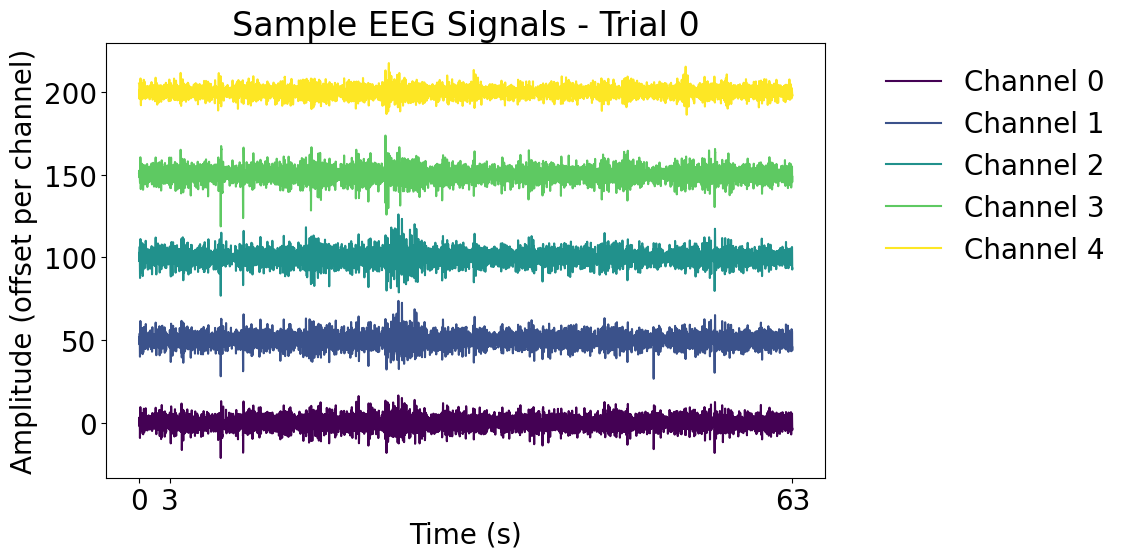

In [5]:
# Define a color cycle for the lines
colors = plt.cm.get_cmap('viridis', 5) # Get 5 distinct colors from 'viridis' colormap

# Plot EEG signals from trial 0 (channels 0-4, 63 seconds)
trial = 0
fs = 128  # sampling rate
time = np.arange(8064) / fs

fig, ax = plt.subplots(figsize=(12, 6))
for ch in range(5):
    ax.plot(time[:], data[trial, ch, :] + ch * 50, label=f"Channel {ch}", color=colors(ch))
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (offset per channel)")
ax.set_title("Sample EEG Signals - Trial 0")

# Place combined legend outside the plot area to the right
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False)

fig.tight_layout(rect=[0, 0, 0.98, 1]) # Adjust layout to make space for the legend
plt.xticks([0,3, 63])
plt.savefig('raw_data_visualization(first 5).svg')
plt.show()
plt.close()


Here, we see the first 5 channels of raw EEG data, by eyes you can tell that at some time session, there are more activities

In [6]:
fs = 128  # Sampling rate
data = data[:,:32, :]
num_trials = data.shape[0]
num_channels = data.shape[1]
stimulus_duration_sec = 60
baseline_duration_sec = 3

# Initialize an array to store the baseline-removed data
# This array will only contain the 60 seconds of stimulus data
data_baseline_removed = np.zeros((num_trials, num_channels, stimulus_duration_sec * fs))

print(f"Original data shape: {data.shape}")
print(f"Shape of baseline-removed data will be: {data_baseline_removed.shape}")

for trial_idx in range(num_trials):
    # Extract the 3-second baseline data for the current trial
    # Shape: (num_channels, baseline_duration_sec * fs) -> (40, 384)
    baseline_data_trial = data[trial_idx, :, :baseline_duration_sec * fs]

    # Reshape baseline data into 1-second segments: (num_channels, baseline_duration_sec, fs)
    baseline_segments_reshaped = baseline_data_trial.reshape(num_channels, baseline_duration_sec, fs)

    # Calculate the mean baseline per second (XB) for this trial
    # Average across the 3 baseline seconds. Resulting shape: (num_channels, fs) -> (40, 128)
    XB_trial = np.mean(baseline_segments_reshaped, axis=1)

    # Extract the 60-second trial data (stimulus period) for the current trial
    # Shape: (num_channels, stimulus_duration_sec * fs) -> (40, 7680)
    trial_data_stimulus = data[trial_idx, :, baseline_duration_sec * fs:]

    # Segment the trial data into 1-second non-overlapping windows
    segmented_trial_data = [trial_data_stimulus[:, j * fs : (j + 1) * fs]
                            for j in range(stimulus_duration_sec)]

    # Perform baseline removal for each segment
    baseline_removed_segments = [Xj - XB_trial for Xj in segmented_trial_data]

    # Concatenate these segments back into a single array for the current trial
    data_baseline_removed[trial_idx] = np.concatenate(baseline_removed_segments, axis=1)

print("Baseline removal complete.")
print("Shape of data_baseline_removed:", data_baseline_removed.shape)

Original data shape: (720, 32, 8064)
Shape of baseline-removed data will be: (720, 32, 7680)
Baseline removal complete.
Shape of data_baseline_removed: (720, 32, 7680)


### Visualize Baseline-Removed EEG Signals

We then visualize the EEG signals after baseline removal for comparison. We will plot the same trial and channels as before, but only for the stimulus period (60 seconds).

/tmp/ipykernel_979/3075924596.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('viridis', 5) # Get 5 distinct colors from 'viridis' colormap


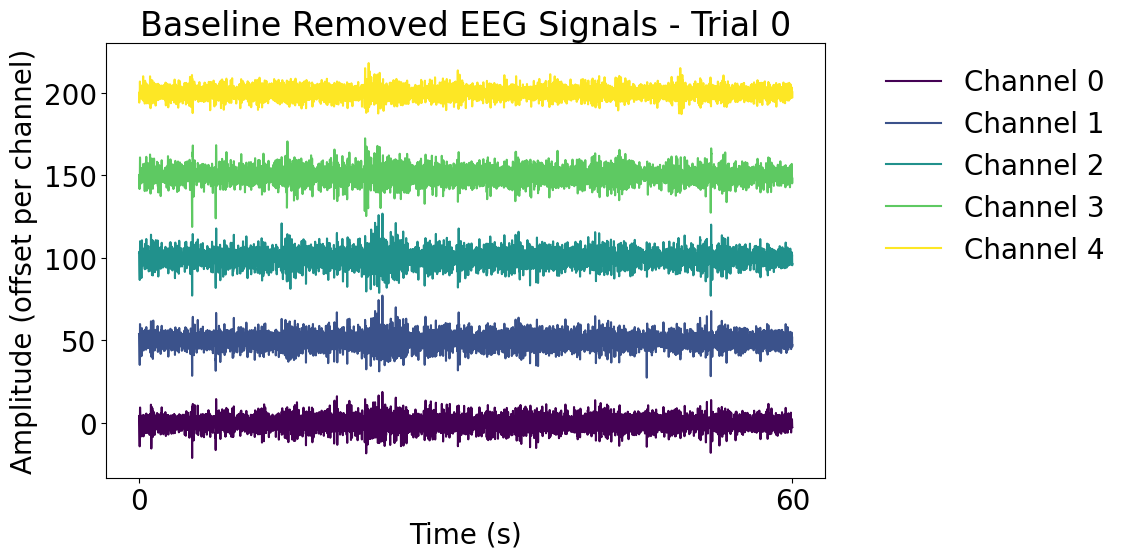

In [7]:
# Define a color cycle for the lines
colors = plt.cm.get_cmap('viridis', 5) # Get 5 distinct colors from 'viridis' colormap

# Plot EEG signals from trial 0 after baseline removal (channels 0-4, 60s)

trial = 0
fs = 128  # Sampling rate, if not defined from previous cells
stimulus_duration_sec = 60 # Corrected to match the actual length of data_baseline_removed

# Time array for the stimulus period (60 seconds)
time_stimulus = np.arange(stimulus_duration_sec * fs) / fs

fig, ax = plt.subplots(figsize=(12, 6))
for ch in range(5):
    ax.plot(time_stimulus[:60*fs], data_baseline_removed[trial, ch, :60*fs] + ch * 50, label=f"Channel {ch}", color=colors(ch))
ax.set_xlabel("Time (s)")
ax.set_ylabel("Amplitude (offset per channel)")
ax.set_title("Baseline Removed EEG Signals - Trial 0") # Corrected title

# Place combined legend outside the plot area to the right
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False)
plt.xticks([0,60])
fig.tight_layout(rect=[0, 0, 0.98, 1]) # Adjust layout to make space for the legend
plt.savefig('filtered_data_visualization(first 5).svg')
plt.show()

## Data Preprocessing + feature extraction

### Spatial feature extraction: Microstate Analysis with DTAAHC

Microstate analysis is a method used to segment continuous EEG data into a series of quasi-stable brain states, or "microstates." Each microstate is characterized by a unique topography of electrical potentials across the scalp, reflecting distinct neuronal networks.

**Dual Threshold-based Atomize and Agglomerate Hierarchical Clustering (DTAAHC)** is a specific algorithm for microstate analysis. It works by:
1.  **Atomize**: Initially treating each time point (often at a Global Field Power peak) as its own cluster.
2.  **Agglomerate**: Iteratively merging the two most similar clusters into a new cluster.
3.  **Dual Thresholds**: This process continues until predefined thresholds for **Global Explained Variance (GEV)** and **Global Map Dissimilarity (GMD)** are met. The goal is to find a set of microstates that explain a high percentage of the variance in the data (high GEV) while being sufficiently distinct from each other (low GMD).

In this analysis, we'll use:
*   **GEV threshold = 85%**: The derived microstate maps should collectively explain at least 85% of the variance of the data at GFP peaks.
*   **GMD threshold = 0.2**: The global map dissimilarity between the resulting microstates should be less than 0.2, indicating distinct topographies.

First, we need to prepare our `data_baseline_removed` for this analysis by reshaping it into a 2D array of time points by channels. Then, we will calculate the Global Field Power (GFP) to identify the most representative time points for microstate segmentation.

Original data_baseline_removed shape: (400, 32, 7680)
Reshaped EEG data for microstate analysis (time_points, channels): (3072000, 32)
GFP shape: (3072000,)


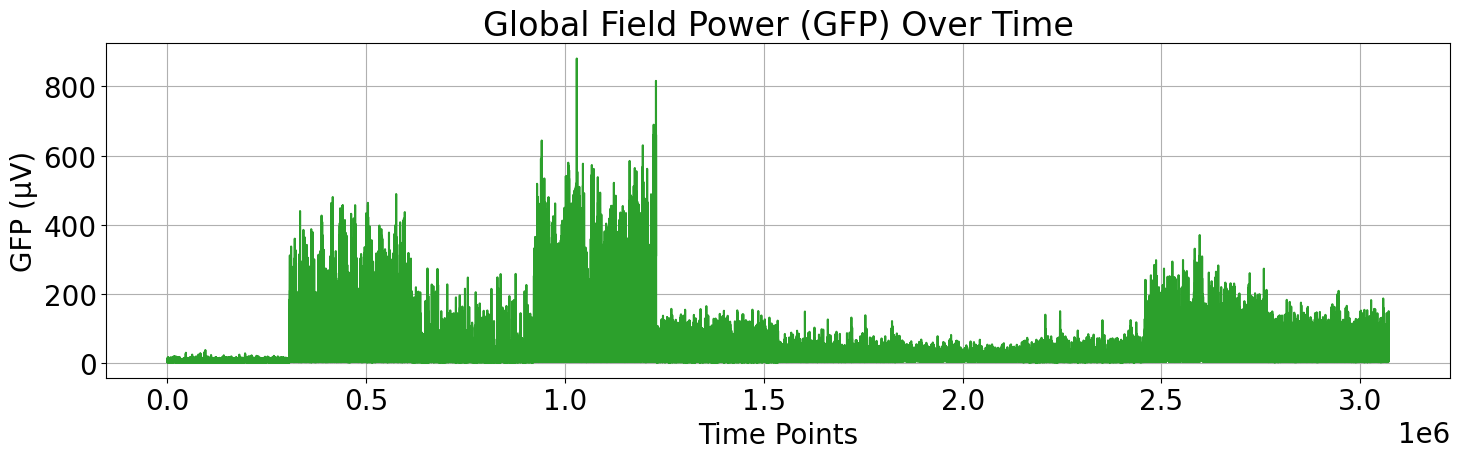

In [8]:

# Ensure data_baseline_removed is available from previous steps
# Shape: (num_trials, num_channels, total_stimulus_samples)
data_baseline_removed = data_baseline_removed[:400, :, :]
num_trials, num_channels, total_stimulus_samples = data_baseline_removed.shape

# Reshape data into (time_points, channels) for microstate analysis
# Transpose to move channels to the last dimension, then reshape
eeg_data_2d = data_baseline_removed.transpose(0, 2, 1).reshape(-1, num_channels)

print(f"Original data_baseline_removed shape: {data_baseline_removed.shape}")
print(f"Reshaped EEG data for microstate analysis (time_points, channels): {eeg_data_2d.shape}")

def calculate_gfp(data_2d):
    """
    Calculates the Global Field Power (GFP) for each time point in the EEG data.
    GFP is the standard deviation of the potential across all electrodes at a given time point.

    Args:
        data_2d (np.ndarray): EEG data in (time_points, channels) format.

    Returns:
        np.ndarray: Array of GFP values for each time point.
    """
    # Calculate the standard deviation across the channel dimension (axis=1)
    return np.std(data_2d, axis=1)

# Calculate GFP for the entire dataset
gfp = calculate_gfp(eeg_data_2d)

print(f"GFP shape: {gfp.shape}")

# Optionally, visualize GFP
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(gfp, color='#2ca02c') # Using a shade of green for single line plot
ax.set_title('Global Field Power (GFP) Over Time')
ax.set_xlabel('Time Points')
ax.set_ylabel('GFP (µV)')
ax.grid(True)
fig.tight_layout() # No legend to place outside
plt.savefig('gfp.svg')
plt.show()

### Identifying GFP Peaks and Extracting Spatial Maps

Microstates are typically identified at the peaks of the Global Field Power (GFP) curve. These peaks represent moments of maximal synchronization and neural activity across the scalp. By focusing on these time points, we ensure that our microstate analysis is based on robust and spatially distinct brain states. After identifying the peaks, we will extract the corresponding spatial voltage maps, which will serve as the input for our clustering algorithm.

Number of GFP peaks identified: 50219
Shape of spatial maps at GFP peaks: (50219, 32)


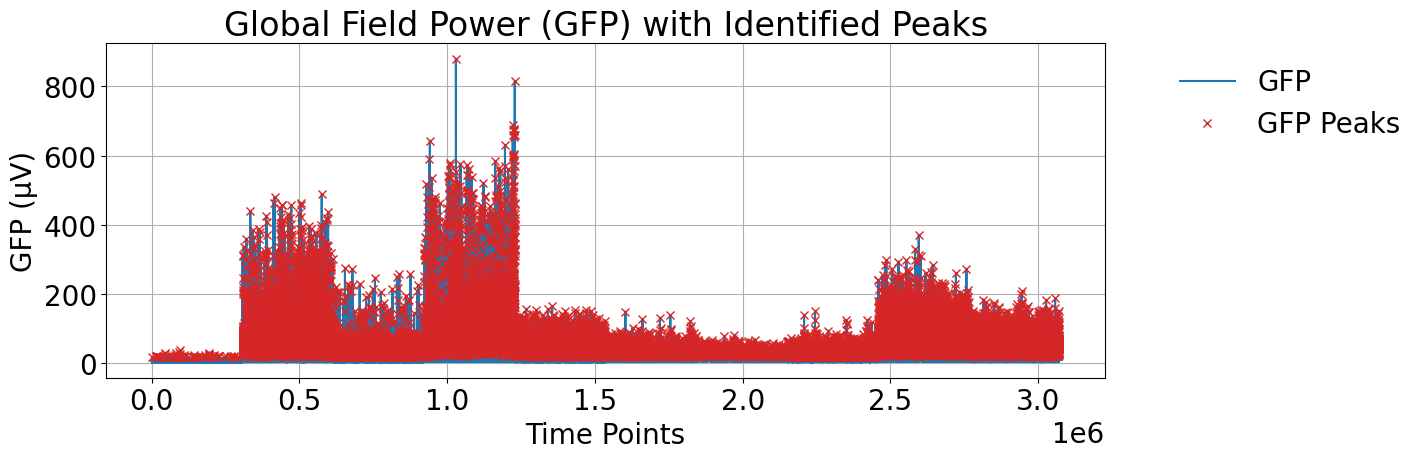

In [9]:
from scipy.signal import find_peaks
def identify_gfp_peaks(gfp_values, prominence=0.1, distance=1):
    """
    Identifies local maxima (peaks) in the GFP curve. And returns
    np.ndarray: Array of indices corresponding to GFP peak locations.
    """
    # 'peaks' will contain the indices of the GFP peaks
    peaks, _ = find_peaks(gfp_values, prominence=prominence, distance=distance)
    return peaks

# Identify GFP peaks
gfp_peak_indices = identify_gfp_peaks(gfp, prominence=np.std(gfp)*0.5, distance=int(fs/4)) # Example thresholds

print(f"Number of GFP peaks identified: {len(gfp_peak_indices)}")

# Extract spatial maps at GFP peaks
# Each map is a vector of (num_channels) representing the potential at electrodes
maps_at_gfp_peaks = eeg_data_2d[gfp_peak_indices, :]

print(f"Shape of spatial maps at GFP peaks: {maps_at_gfp_peaks.shape}")

# Visualize GFP with peaks
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(gfp, label='GFP', color='#1f77b4')
ax.plot(gfp_peak_indices, gfp[gfp_peak_indices], "x", label='GFP Peaks', color='#d62728') # Red for peaks
ax.set_title('Global Field Power (GFP) with Identified Peaks')
ax.set_xlabel('Time Points')
ax.set_ylabel('GFP (µV)')

# Place combined legend outside the plot area to the right
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False)

ax.grid(True)
fig.tight_layout(rect=[0, 0, 0.98, 1]) # Adjust layout to make space for the legend
plt.savefig('gfp_with_peaks.svg')
plt.show()

### Dual Threshold Atomize and Agglomerate Hierarchical Clustering (DTAAHC)

#### K-Means Pre-clustering for Speed Optimization

Given the large number of GFP peaks identified (50219), performing DTAAHC directly on all these points is computationally very expensive and time-consuming. To optimize this process, we will first apply **K-Means clustering** to reduce the number of data points before running the DTAAHC algorithm.

Here's why this helps:
*   **Dimensionality Reduction**: K-Means will group similar GFP peak maps into a smaller number of centroids.
*   **Computational Efficiency**: DTAAHC will then operate on these fewer K-Means centroids, significantly speeding up the iterative merging process.

We will set the number of K-Means clusters (`n_clusters`) to 1000 as a reasonable starting point. The centroids from K-Means will serve as the input for DTAAHC.

In [10]:
k_means_n_clusters = 200 # A reasonable number to reduce data scale significantly

print(f"Performing K-Means pre-clustering on {maps_at_gfp_peaks.shape[0]} GFP peaks into {k_means_n_clusters} clusters...")

# Directly use scikit-learn's KMeans for CPU-based clustering as requested.
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=k_means_n_clusters, random_state=42, n_init=10) # n_init for robust initialization
kmeans.fit(maps_at_gfp_peaks)
kmeans_centroids = kmeans.cluster_centers_
kmeans_labels = kmeans.labels_

print(f"K-Means pre-clustering complete.")
print(f"Shape of K-Means centroids (new input for DTAAHC): {kmeans_centroids.shape}")

Performing K-Means pre-clustering on 50219 GFP peaks into 200 clusters...
K-Means pre-clustering complete.
Shape of K-Means centroids (new input for DTAAHC): (200, 32)


In [11]:
def calculate_gev(data_at_peaks, cluster_assignments, microstate_centroids):
    """
    Calculates the Global Explained Variance (GEV). And returns
    float of the GEV value.
    """
    total_variance = np.sum(data_at_peaks**2)
    explained_variance = 0
    for i, centroid_map in enumerate(microstate_centroids):
        # Get data points assigned to this centroid
        points_in_cluster = data_at_peaks[cluster_assignments == i]
        if len(points_in_cluster) > 0:
            # Project data points onto the centroid and sum squared projections
            # Normalize centroid for proper projection
            norm_centroid = centroid_map / np.linalg.norm(centroid_map)
            projections = np.dot(points_in_cluster, norm_centroid)
            explained_variance += np.sum(projections**2)

    if total_variance == 0: # Avoid division by zero
        return 0
    return (explained_variance / total_variance) * 100

def calculate_gmd(microstate_centroids):
    """
    Calculates the Global Map Dissimilarity (GMD).And
    returns the GMD value (average dissimilarity between all unique pairs of microstates).
    """
    if len(microstate_centroids) < 2:
        return 0.0 # GMD is 0 if there's only one or zero microstates

    dissimilarities = []
    # Calculate cosine dissimilarity for all unique pairs
    for i in range(len(microstate_centroids)):
        for j in range(i + 1, len(microstate_centroids)):
            # Cosine similarity ranges from -1 (opposite) to 1 (same)
            # Dissimilarity = 1 - |cosine_similarity|
            sim = cosine_similarity(microstate_centroids[i].reshape(1, -1),
                                    microstate_centroids[j].reshape(1, -1))[0][0]
            dissimilarities.append(1 - abs(sim))

    return np.mean(dissimilarities)

def dual_threshold_aahc(maps_at_gfp_peaks, target_gev=85, target_gmd=0.2, max_microstates=10):
    """
    Performs Dual Threshold Atomize and Agglomerate Hierarchical Clustering
    and returns A tuple containing:
            - np.ndarray: The identified microstate centroids.
            - np.ndarray: Cluster assignments for each GFP peak.
            - list: List of (num_clusters, GEV, GMD) at each merge step.
    """
    n_peaks, n_channels = maps_at_gfp_peaks.shape

    # 1. Atomize: Start with each peak as its own cluster
    clusters = [[i] for i in range(n_peaks)] # List of lists of peak indices
    cluster_assignments = np.arange(n_peaks) # Initial assignment

    # Store centroids and track merges
    centroids = np.copy(maps_at_gfp_peaks) # Initially, each map is its own centroid

    # History of clustering metrics
    history = []

    # Agglomerate until thresholds are met or max_microstates is reached
    while len(clusters) > 1 and len(clusters) > max_microstates:
        # Find the two most similar clusters to merge
        max_similarity = -np.inf
        merge_idx1, merge_idx2 = -1, -1

        # Iterate through all unique pairs of current centroids
        for i in range(len(centroids)):
            for j in range(i + 1, len(centroids)):
                # Cosine similarity between centroid maps
                sim = cosine_similarity(centroids[i].reshape(1, -1),
                                        centroids[j].reshape(1, -1))[0][0]
                if sim > max_similarity:
                    max_similarity = sim
                    merge_idx1, merge_idx2 = i, j

        if merge_idx1 == -1: # No valid merge found, stop
            break

        # Merge the clusters
        merged_cluster_indices = clusters[merge_idx1] + clusters[merge_idx2]
        new_centroid = np.mean(maps_at_gfp_peaks[merged_cluster_indices], axis=0)

        # Update clusters and centroids
        new_clusters = []
        new_centroids_list = []

        # Keep existing clusters/centroids not involved in merge
        for k, current_cluster in enumerate(clusters):
            if k != merge_idx1 and k != merge_idx2:
                new_clusters.append(current_cluster)
                new_centroids_list.append(centroids[k])

        # Add the new merged cluster and its centroid
        new_clusters.append(merged_cluster_indices)
        new_centroids_list.append(new_centroid)

        clusters = new_clusters
        centroids = np.array(new_centroids_list)

        # OPTIMIZED: Re-assign cluster_assignments based on nearest centroid using vectorization
        # This ensures all points are assigned to the current best-fitting centroid
        similarities_to_centroids = cosine_similarity(maps_at_gfp_peaks, centroids)
        cluster_assignments = np.argmax(similarities_to_centroids, axis=1)

        current_gev = calculate_gev(maps_at_gfp_peaks, cluster_assignments, centroids)
        current_gmd = calculate_gmd(centroids)
        history.append((len(clusters), current_gev, current_gmd))

        # Check dual thresholds
        if current_gev >= target_gev and current_gmd <= target_gmd:
            print(f"Stopping: GEV ({current_gev:.2f}%) >= {target_gev}% and GMD ({current_gmd:.3f}) <= {target_gmd}")
            break

        print(f"  Clusters: {len(clusters)}, GEV: {current_gev:.2f}%, GMD: {current_gmd:.3f}")

    print("DTAAHC complete.")
    return centroids, cluster_assignments, history

# Run the DTAAHC algorithm on the K-Means centroids
microstate_centroids, assignments, history = dual_threshold_aahc(kmeans_centroids, target_gev=75, target_gmd=0.2, max_microstates=10)

# Re-assign original GFP peaks to the identified microstate centroids for final GEV calculation
final_assignments_for_gfp_peaks = np.zeros(maps_at_gfp_peaks.shape[0], dtype=int)
for p_idx in range(maps_at_gfp_peaks.shape[0]):
    current_map = maps_at_gfp_peaks[p_idx]
    similarities = [cosine_similarity(current_map.reshape(1, -1), c.reshape(1, -1))[0][0] for c in microstate_centroids]
    final_assignments_for_gfp_peaks[p_idx] = np.argmax(similarities)

final_gev_on_original_data = calculate_gev(maps_at_gfp_peaks, final_assignments_for_gfp_peaks, microstate_centroids)

print(f"\nIdentified {len(microstate_centroids)} microstates.")
print(f"Final GEV (on original GFP peaks): {final_gev_on_original_data:.2f}%")
print(f"Final GMD: {history[-1][2]:.3f}")

  Clusters: 199, GEV: 100.00%, GMD: 0.771
  Clusters: 198, GEV: 100.00%, GMD: 0.771
  Clusters: 197, GEV: 100.00%, GMD: 0.772
  Clusters: 196, GEV: 100.00%, GMD: 0.773
  Clusters: 195, GEV: 100.00%, GMD: 0.772
  Clusters: 194, GEV: 100.00%, GMD: 0.772
  Clusters: 193, GEV: 100.00%, GMD: 0.773
  Clusters: 192, GEV: 100.00%, GMD: 0.773
  Clusters: 191, GEV: 100.00%, GMD: 0.772
  Clusters: 190, GEV: 100.00%, GMD: 0.772
  Clusters: 189, GEV: 100.00%, GMD: 0.773
  Clusters: 188, GEV: 100.00%, GMD: 0.773
  Clusters: 187, GEV: 100.00%, GMD: 0.774
  Clusters: 186, GEV: 100.00%, GMD: 0.775
  Clusters: 185, GEV: 100.00%, GMD: 0.775
  Clusters: 184, GEV: 100.00%, GMD: 0.776
  Clusters: 183, GEV: 100.00%, GMD: 0.776
  Clusters: 182, GEV: 100.00%, GMD: 0.776
  Clusters: 181, GEV: 100.00%, GMD: 0.776
  Clusters: 180, GEV: 100.00%, GMD: 0.775
  Clusters: 179, GEV: 100.00%, GMD: 0.775
  Clusters: 178, GEV: 100.00%, GMD: 0.774
  Clusters: 177, GEV: 100.00%, GMD: 0.775
  Clusters: 176, GEV: 100.00%, GMD

### GEV and GMD History Plot

To observe how the GEV and GMD metrics evolved during the hierarchical clustering process, we can plot their values against the number of microstates. This helps in understanding the trade-off between the number of microstates and the explained variance/dissimilarity, and can guide in selecting an optimal number of microstates if the thresholds were not strictly met.

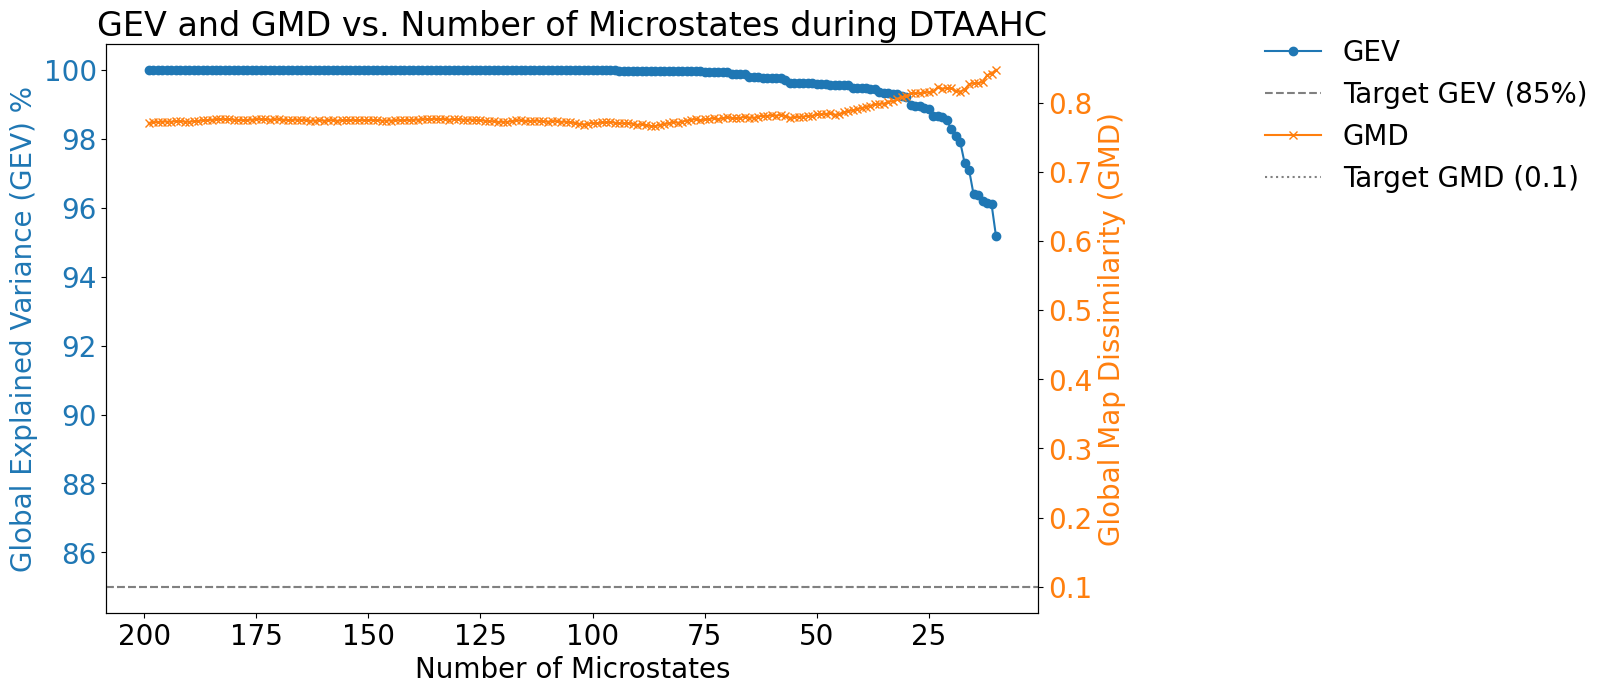

In [18]:
if history:
    num_microstates_list = [h[0] for h in history]
    gev_list = [h[1] for h in history]
    gmd_list = [h[2] for h in history]

    fig, ax1 = plt.subplots(figsize=(12, 7))

    color_gev = '#1f77b4'
    ax1.set_xlabel('Number of Microstates')
    ax1.set_ylabel('Global Explained Variance (GEV) %', color=color_gev)
    ax1.plot(num_microstates_list, gev_list, color=color_gev, marker='o', label='GEV')
    ax1.tick_params(axis='y', labelcolor=color_gev)
    ax1.axhline(y=85, color='gray', linestyle='--', label='Target GEV (85%)')

    ax2 = ax1.twinx()

    color_gmd = '#ff7f0e' # A shade of orange
    ax2.set_ylabel('Global Map Dissimilarity (GMD)', color=color_gmd)
    ax2.plot(num_microstates_list, gmd_list, color=color_gmd, marker='x', label='GMD')
    ax2.tick_params(axis='y', labelcolor=color_gmd)
    ax2.axhline(y=0.1, color='gray', linestyle=':', label='Target GMD (0.1)')

    # Combine legends
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    all_lines = lines1 + lines2
    all_labels = labels1 + labels2

    # Place combined legend outside the plot area to the right
    fig.legend(all_lines, all_labels, loc='upper left', bbox_to_anchor=(1.05, 1), frameon=False)

    fig.tight_layout(rect=[0, 0, 0.98, 1]) # Adjust layout to make space for the legend
    plt.title('GEV and GMD vs. Number of Microstates during DTAAHC')
    plt.savefig('gev_gmd_history.svg')
    plt.gca().invert_xaxis() # Number of microstates decreases as we merge
    plt.show()
else:
    print("No history to plot. The clustering might have stopped prematurely or started with too few data points.")

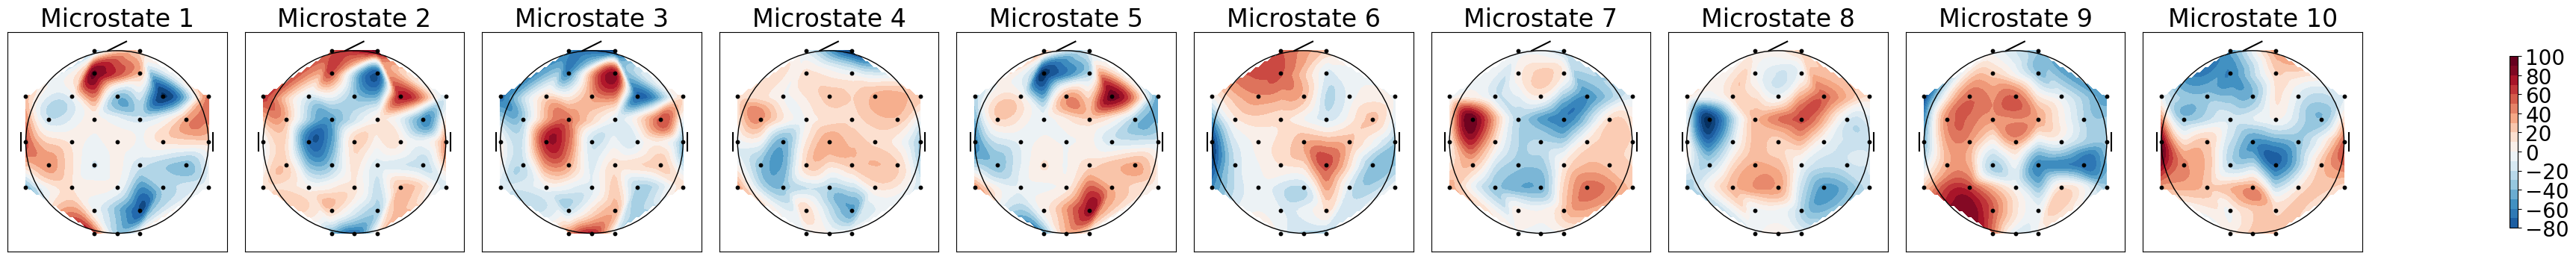

In [13]:

# Using the provided 9x9 channel map to derive 2D electrode positions
eeg_channel_map_9x9 = np.array([
    [-1, -1, -1,  0, -1, 16, -1, -1, -1],  # Fp1(0), Fp2(16)
    [-1, -1, -1,  1, -1, 17, -1, -1, -1],  # AF3(1), AF4(17)
    [ 3, -1,  2, -1, 18, -1, 19, -1, 20],  # F7(3), F3(2), Fz(18), F4(19), F8(20)
    [-1,  4, -1,  5, -1, 22, -1, 21, -1],  # FC5(4), FC1(5), FC2(22), FC6(21)
    [ 7, -1,  6, -1, 23, -1, 24, -1, 25],  # T7(7), C3(6), Cz(23), C4(24), T8(25)
    [-1,  8, -1,  9, -1, 27, -1, 26, -1],  # CP5(8), CP1(9), CP2(27), CP6(26)
    [11, -1, 10, -1, 15, -1, 28, -1, 29],  # P7(11), P3(10), Pz(15), P4(28), P8(29)
    [-1, -1, -1, 12, -1, 30, -1, -1, -1],  # PO3(12), PO4(30)
    [-1, -1, -1, 13, 14, 31, -1, -1, -1]   # O1(13), Oz(14), O2(31)
])

# Initialize an array to store the 2D coordinates of the 32 channels
electrode_positions = np.zeros((32, 2))

# Map the 9x9 grid positions to x,y coordinates (e.g., -1 to 1 range)
# Assuming (0,0) of the grid maps to (-1,1) in Cartesian, and (8,8) maps to (1,-1)
for r in range(9):
    for c in range(9):
        channel_idx = eeg_channel_map_9x9[r, c]
        if channel_idx != -1 and channel_idx < 32:
            # Scale column index (0-8) to x-coordinate (-1 to 1)
            x = (c / 8.0) * 2 - 1
            # Scale row index (0-8) to y-coordinate (1 to -1) (y decreases with increasing row)
            y = 1 - (r / 8.0) * 2
            electrode_positions[channel_idx] = [x, y]

# The condition electrode_positions.shape[0] != num_channels will now be false
# as we are explicitly generating 32 positions for 32 channels.
# So, the else block for topographical plotting will always be executed.

# Setup for topographical plotting
grid_resolution = 67 # Standard for many EEG plots
xi = np.linspace(-1, 1, grid_resolution)
yi = np.linspace(-1, 1, grid_resolution)
grid_x, grid_y = np.meshgrid(xi, yi)

fig, axes = plt.subplots(1, len(microstate_centroids), figsize=(4 * len(microstate_centroids), 4))
if len(microstate_centroids) == 1: # Handle case of single microstate
    axes = [axes]

for i, centroid in enumerate(microstate_centroids):
    # Interpolate the data onto a grid
    grid_z = griddata(electrode_positions, centroid, (grid_x, grid_y), method='cubic')

    ax = axes[i]
    contour_plot = ax.contourf(grid_x, grid_y, grid_z, levels=20, cmap='RdBu_r', vmin=-np.max(np.abs(centroid)), vmax=np.max(np.abs(centroid)))
    ax.scatter(electrode_positions[:, 0], electrode_positions[:, 1], c='k', s=10) # Plot electrodes
    ax.set_title(f'Microstate {i+1}')
    ax.set_aspect('equal', adjustable='box')
    ax.set_xticks([])
    ax.set_yticks([])

    # Draw a circle for the head and lines for nose/ears
    circle = plt.Circle((0, 0), 1, color='black', fill=False)
    ax.add_artist(circle)
    ax.plot([-0.1, 0.1], [1, 1.1], 'k-') # Nose
    ax.plot([-1.05, -1.05], [0.1, -0.1], 'k-') # Left ear
    ax.plot([1.05, 1.05], [0.1, -0.1], 'k-') # Right ear
    ax.set_xlim([-1.2, 1.2])
    ax.set_ylim([-1.2, 1.2])
plt.savefig('microstate_topographies.svg')

plt.tight_layout()
plt.colorbar(contour_plot, ax=axes.ravel().tolist(), orientation='vertical', shrink=0.7)
plt.savefig('microstate_topographies_color_bar.svg')
plt.show()

### Temporal feature extraction
Other than spatial features, EEG contains rich temporal features as well. Here we use Differential Entropy (DE) method to caluclate the temporal features for EEG signals. Firstly, we need to filter the data using bandpass filter for 4 bands: **alpha, beta, gamma, theta**:

`theta`: (4, 8),
`alpha`: (8, 13),
`beta`: (13, 31),
`gamma`: (31, 45)

In [14]:
output_file_path = "filtered_eeg_bands.pkl" # Define the path for the pickle file

run_filtering = False # Initialize run_filtering to False

# Check if the filtered data already exists to avoid re-running the filtering process
if os.path.exists(output_file_path):
    try:
        print(f"Found existing filtered EEG bands data at {output_file_path}. Loading data...")
        with open(output_file_path, 'rb') as f:
            filtered_eeg_bands = pickle.load(f)
        print(f"Loaded filtered_eeg_bands keys: {filtered_eeg_bands.keys()}")
        # If loaded successfully, run_filtering remains False, so no re-filtering.
    except Exception as e:
        print(f"Error loading filtered EEG bands data: {e}. Re-running filtering...")
        run_filtering = True # Set to True to re-run filtering
else:
    print(f"Filtered EEG bands data not found at {output_file_path}. Proceeding with filtering...")
    run_filtering = True # Set to True as file was not found

if run_filtering:
    # Define EEG channels (using 32 channels from the 'data' variable)
    eeg_data = data_baseline_removed[:, :32, :]

    # Define frequency bands
    frequency_bands = {
        'theta': (4, 8),
        'alpha': (8, 13),
        'beta': (13, 31),
        'gamma': (31, 45)
    }
    fs = 128  # Sampling rate
    segment_duration_seconds = 1
    samples_per_segment = int(fs * segment_duration_seconds)

    # Butterworth bandpass filter function
    def butter_bandpass(lowcut, highcut, fs, order=4): # User specified fourth-order
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], btype='band')
        return b, a

    def bandpass_filter(data_segment, lowcut, highcut, fs, order=4):
        b, a = butter_bandpass(lowcut, highcut, fs, order=order)
        y = lfilter(b, a, data_segment)
        return y

    # Store filtered segments for each band
    filtered_eeg_bands = {} # Dictionary to hold data for each band

    num_trials, num_channels, num_time_points = eeg_data.shape
    num_segments = num_time_points // samples_per_segment

    print(f"Original EEG data shape: {eeg_data.shape}")
    print(f"Number of 1-second segments per trial: {num_segments}")

    for band_name, (lowcut, highcut) in frequency_bands.items():
        print(f"\nFiltering for {band_name} band ({lowcut}-{highcut} Hz)...")

        # Apply filter to the entire time series for each channel and trial
        # This greatly reduces the number of filter calls and uses lfilter more efficiently.
        filtered_full_time_data = np.zeros_like(eeg_data, dtype=np.float32)
        for trial_idx in range(num_trials):
            for ch_idx in range(num_channels):
                # Filter the entire time series for the current channel and trial
                filtered_full_time_data[trial_idx, ch_idx, :] = bandpass_filter(
                    eeg_data[trial_idx, ch_idx, :], lowcut, highcut, fs
                )

        # Reshape the filtered data into 1-second segments
        # The reshape and transpose ensure the final dimensions are (num_trials, num_segments, num_channels, samples_per_segment)
        band_filtered_data = filtered_full_time_data.reshape(
            num_trials, num_channels, num_segments, samples_per_segment
        ).transpose(0, 2, 1, 3)

        filtered_eeg_bands[band_name] = band_filtered_data
        print(f"Shape of filtered data for {band_name} band: {band_filtered_data.shape}")

    # Save the filtered data immediately after creation if filtering was performed
    try:
        with open(output_file_path, 'wb') as f:
            pickle.dump(filtered_eeg_bands, f)
        print(f"\nFiltered EEG bands data saved to {output_file_path}")
    except Exception as e:
        print(f"Error saving filtered EEG bands data: {e}")

Filtered EEG bands data not found at filtered_eeg_bands.pkl. Proceeding with filtering...
Original EEG data shape: (400, 32, 7680)
Number of 1-second segments per trial: 60

Filtering for theta band (4-8 Hz)...
Shape of filtered data for theta band: (400, 60, 32, 128)

Filtering for alpha band (8-13 Hz)...
Shape of filtered data for alpha band: (400, 60, 32, 128)

Filtering for beta band (13-31 Hz)...
Shape of filtered data for beta band: (400, 60, 32, 128)

Filtering for gamma band (31-45 Hz)...
Shape of filtered data for gamma band: (400, 60, 32, 128)

Filtered EEG bands data saved to filtered_eeg_bands.pkl


### 2. Approximate Entropy (Differential Entropy) Features

I will now calculate the Differential Entropy (DE) for each 1-second segment, for each channel, and for each frequency band. The formula used is DE(X) = 1/2 * log(2 * pi * e * (sigma^2)), where `X` is a one-second EEG signal segment and `sigma` is its standard deviation.

In [ ]:
# Initialize a dictionary to store DE features for each band
de_features_bands = {}

# Assuming filtered_eeg_bands is available from previous steps
# filtered_eeg_bands structure: {'band_name': (num_trials, num_segments, num_channels, samples_per_segment)}

print("Calculating Differential Entropy (DE) features...")

for band_name, band_data in filtered_eeg_bands.items():
    print(f"Processing {band_name} band...")
    # band_data shape: (num_trials, num_segments, num_channels, samples_per_segment)
    num_trials, num_segments, num_channels, samples_per_segment = band_data.shape

    # Initialize an array to store DE features for the current band
    # Shape: (num_trials, num_segments, num_channels)
    de_features = np.zeros((num_trials, num_segments, num_channels))

    for trial_idx in range(num_trials):
        for seg_idx in range(num_segments):
            for ch_idx in range(num_channels):
                # Extract the 1-second EEG signal segment
                segment = band_data[trial_idx, seg_idx, ch_idx, :]

                # Calculate the standard deviation (sigma) of the segment
                sigma_squared = np.var(segment) # Variance is sigma^2

                # Avoid log of zero or negative numbers
                if sigma_squared > 0:
                    # Calculate Differential Entropy: 0.5 * log(2 * pi * e * sigma^2)
                    # Using np.log for natural logarithm
                    de = 0.5 * np.log(2 * np.pi * np.e * sigma_squared)
                else:
                    de = 0.0 # Assign 0 if variance is zero (e.g., flat signal)

                de_features[trial_idx, seg_idx, ch_idx] = de

    de_features_bands[band_name] = de_features
    print(f"Shape of DE features for {band_name}: {de_features.shape}")

print("Differential Entropy calculation complete.")

Calculating Differential Entropy (DE) features...
Processing theta band...
Shape of DE features for theta: (720, 60, 32)
Processing alpha band...
Shape of DE features for alpha: (720, 60, 32)
Processing beta band...
Shape of DE features for beta: (720, 60, 32)
Processing gamma band...
Shape of DE features for gamma: (720, 60, 32)
Differential Entropy calculation complete.


### 3. Normalize Differential Entropy Features

Next, I will normalize the calculated Differential Entropy features for each channel within each frequency band using the min-max scaling formula: `x_i = (x_i - min(x_i))/(max(x_i) - min(x_i))`.

In [ ]:
normalized_de_features_bands = {}

for band_name, de_features in de_features_bands.items():
    # de_features shape: (num_trials, num_segments, num_channels)
    num_trials, num_segments, num_channels = de_features.shape

    # Reshape to (total_instances, num_channels) for normalization per channel
    # total_instances = num_trials * num_segments
    reshaped_de = de_features.reshape(-1, num_channels)

    normalized_de = np.zeros_like(reshaped_de)

    print(f"Normalizing DE features for {band_name} band...")
    for ch_idx in range(num_channels):
        channel_data = reshaped_de[:, ch_idx]
        min_val = np.min(channel_data)
        max_val = np.max(channel_data)

        if (max_val - min_val) > 0: # Avoid division by zero
            normalized_de[:, ch_idx] = (channel_data - min_val) / (max_val - min_val)
        else:
            normalized_de[:, ch_idx] = 0.5 # Assign a neutral value if all are same

    # Reshape back to original DE feature shape: (num_trials, num_segments, num_channels)
    normalized_de_reshaped = normalized_de.reshape(num_trials, num_segments, num_channels)
    normalized_de_features_bands[band_name] = normalized_de_reshaped
    print(f"Shape of normalized DE features for {band_name}: {normalized_de_reshaped.shape}")

Normalizing DE features for theta band...
Shape of normalized DE features for theta: (720, 60, 32)
Normalizing DE features for alpha band...
Shape of normalized DE features for alpha: (720, 60, 32)
Normalizing DE features for beta band...
Shape of normalized DE features for beta: (720, 60, 32)
Normalizing DE features for gamma band...
Shape of normalized DE features for gamma: (720, 60, 32)


### 4. Spatial Mapping to a 9x9 Matrix

To incorporate spatial information, I will map the normalized differential entropy features for the first 32 EEG channels (the DEAP dataset has 32 EEG and 8 peripheral channels) onto a 9x9 matrix. Locations not corresponding to an EEG channel will be set to 0. This step requires a predefined spatial layout of the 32 EEG channels on a grid.

In [ ]:
# Define a 9x9 grid mapping for 32 EEG channels
# This is a common representation for 32-channel EEG layouts.
# The numbers correspond to the channel index in the DEAP dataset (0-31).
# Peripheral channels (32-39) are ignored for spatial mapping.
# -1 indicates an empty/unmapped position.

eeg_channel_map_9x9 = np.array([
    [-1, -1, -1,  0, -1, 16, -1, -1, -1],  # Fp1(0), Fp2(16)
    [-1, -1, -1,  1, -1, 17, -1, -1, -1],  # AF3(1), AF4(17)
    [ 3, -1,  2, -1, 18, -1, 19, -1, 20],  # F7(3), F3(2), Fz(18), F4(19), F8(20)
    [-1,  4, -1,  5, -1, 22, -1, 21, -1],  # FC5(4), FC1(5), FC2(22), FC6(21)
    [ 7, -1,  6, -1, 23, -1, 24, -1, 25],  # T7(7), C3(6), Cz(23), C4(24), T8(25)
    [-1,  8, -1,  9, -1, 27, -1, 26, -1],  # CP5(8), CP1(9), CP2(27), CP6(26)
    [11, -1, 10, -1, 15, -1, 28, -1, 29],  # P7(11), P3(10), Pz(15), P4(28), P8(29)
    [-1, -1, -1, 12, -1, 30, -1, -1, -1],  # PO3(12), PO4(30)
    [-1, -1, -1, 13, 14, 31, -1, -1, -1]   # O1(13), Oz(14), O2(31)
])

spatial_de_matrices_bands = {}

for band_name, normalized_de_features in normalized_de_features_bands.items():
    # normalized_de_features shape: (num_trials, num_segments, num_channels)
    num_trials, num_segments, num_channels = normalized_de_features.shape

    # Initialize array for spatially mapped DE features for the current band
    # Shape: (num_trials, num_segments, 9, 9)
    spatial_matrices = np.zeros((num_trials, num_segments, 9, 9))

    print(f"Mapping {band_name} DE features to 9x9 spatial matrices...")
    for trial_idx in range(num_trials):
        for seg_idx in range(num_segments):
            current_segment_de = normalized_de_features[trial_idx, seg_idx, :]
            mapped_matrix = np.zeros((9, 9))

            for r in range(9):
                for c in range(9):
                    channel_idx = eeg_channel_map_9x9[r, c]
                    if channel_idx != -1 and channel_idx < 32: # Only map the first 32 EEG channels
                        mapped_matrix[r, c] = current_segment_de[channel_idx]
            spatial_matrices[trial_idx, seg_idx] = mapped_matrix

    spatial_de_matrices_bands[band_name] = spatial_matrices
    print(f"Shape of spatial matrices for {band_name}: {spatial_matrices.shape}")

Mapping theta DE features to 9x9 spatial matrices...
Shape of spatial matrices for theta: (720, 60, 9, 9)
Mapping alpha DE features to 9x9 spatial matrices...
Shape of spatial matrices for alpha: (720, 60, 9, 9)
Mapping beta DE features to 9x9 spatial matrices...
Shape of spatial matrices for beta: (720, 60, 9, 9)
Mapping gamma DE features to 9x9 spatial matrices...
Shape of spatial matrices for gamma: (720, 60, 9, 9)


### 5. Nonlinear Transformation and 3D Input Structure

Finally, I will apply a non-linear transformation to each spatial matrix: `M_1 = log(M+1)` and then multiply by 255. Both the original (mapped) and the transformed matrices will be combined to form an 8-channel 3D input (`C * H * W`) for the neural network, where `C=8` (4 frequency bands * 2 types of matrices).

In [ ]:
final_nn_input = []

# Assuming all bands have the same number of trials and segments
num_trials, num_segments, H, W = next(iter(spatial_de_matrices_bands.values())).shape

for trial_idx in range(num_trials):
    trial_data = []
    for seg_idx in range(num_segments):
        segment_matrices = []
        for band_name in ['theta', 'alpha', 'beta', 'gamma']:
            M = spatial_de_matrices_bands[band_name][trial_idx, seg_idx]

            # Original mapped matrix
            segment_matrices.append(M)

            # Nonlinear transformation: M_1 = log(M+1) * 255
            M_1 = np.log(M + 1) * 255
            segment_matrices.append(M_1)

        # Stack the 8 matrices (4 bands * 2 types) along a new channel dimension
        # Resulting shape for a segment: (C, H, W) = (8, 9, 9)
        segment_stacked_matrices = np.stack(segment_matrices, axis=0)
        trial_data.append(segment_stacked_matrices)

    # Stack all segments for the current trial
    final_nn_input.append(np.array(trial_data))

# Convert list of trials into a single numpy array
# Final shape: (num_trials, num_segments, C, H, W)
final_nn_input_array = np.array(final_nn_input)

print(f"Final Neural Network Input Shape: {final_nn_input_array.shape}")

Final Neural Network Input Shape: (720, 60, 8, 9, 9)


### Visualize a Sample 9x9 Spatial Matrix

Let's visualize one of the 9x9 matrices to understand the spatial mapping. We will take the first trial, first segment, and the original mapped matrix for the theta band as an example.

### Average 9x9 Spatial Matrix for Theta Band

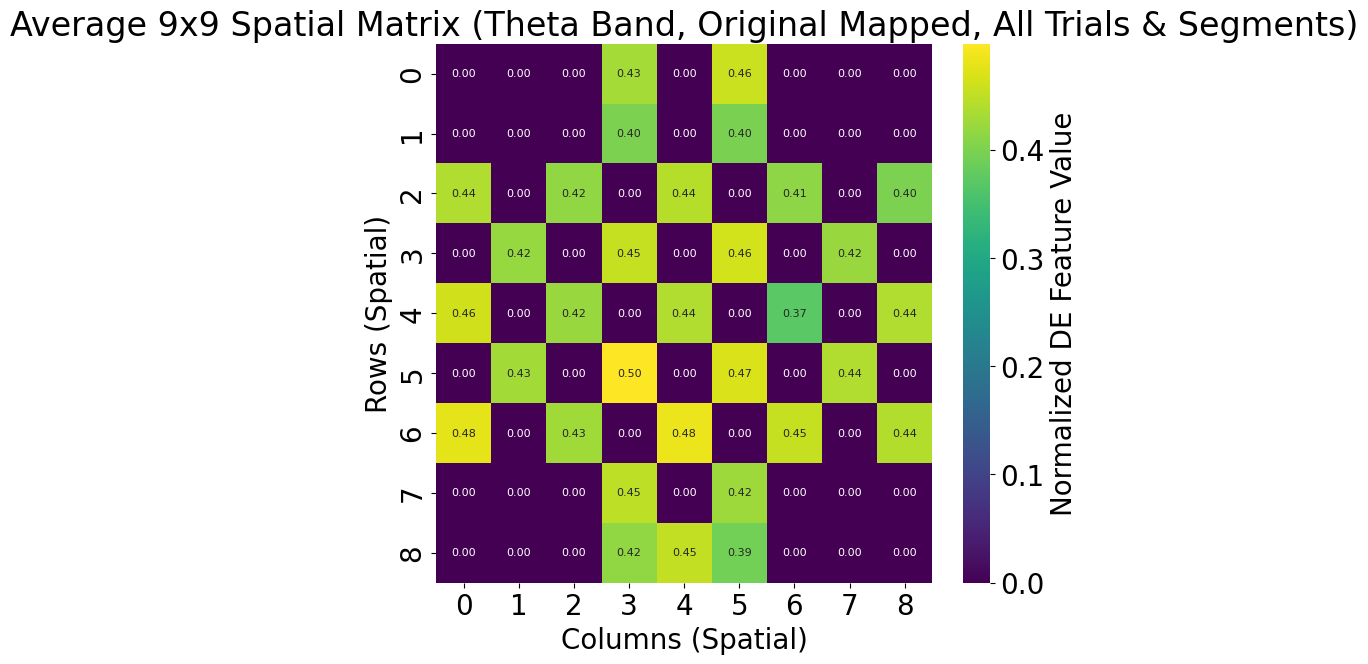

In [ ]:
# Calculate the average spatial matrix for the theta band (index 0 for C) across all trials and all segments
# We take the mean over axis 0 (trials) and axis 1 (segments)
example_matrix = final_nn_input_array[:, :, 0, :, :].mean(axis=(0, 1))

plt.figure(figsize=(8, 7))
sns.heatmap(example_matrix, annot=True, cmap='viridis', fmt=".2f", cbar_kws={'label': 'Normalized DE Feature Value'}, annot_kws={"size": 8})
plt.title('Average 9x9 Spatial Matrix (Theta Band, Original Mapped, All Trials & Segments)')
plt.xlabel('Columns (Spatial)')
plt.ylabel('Rows (Spatial)')
plt.savefig('Average 9x9 Spatial Matrix (Theta Band, Original Mapped, All Trials & Segments).svg')
plt.show()

### Average 9x9 Spatial Matrix for Alpha Band

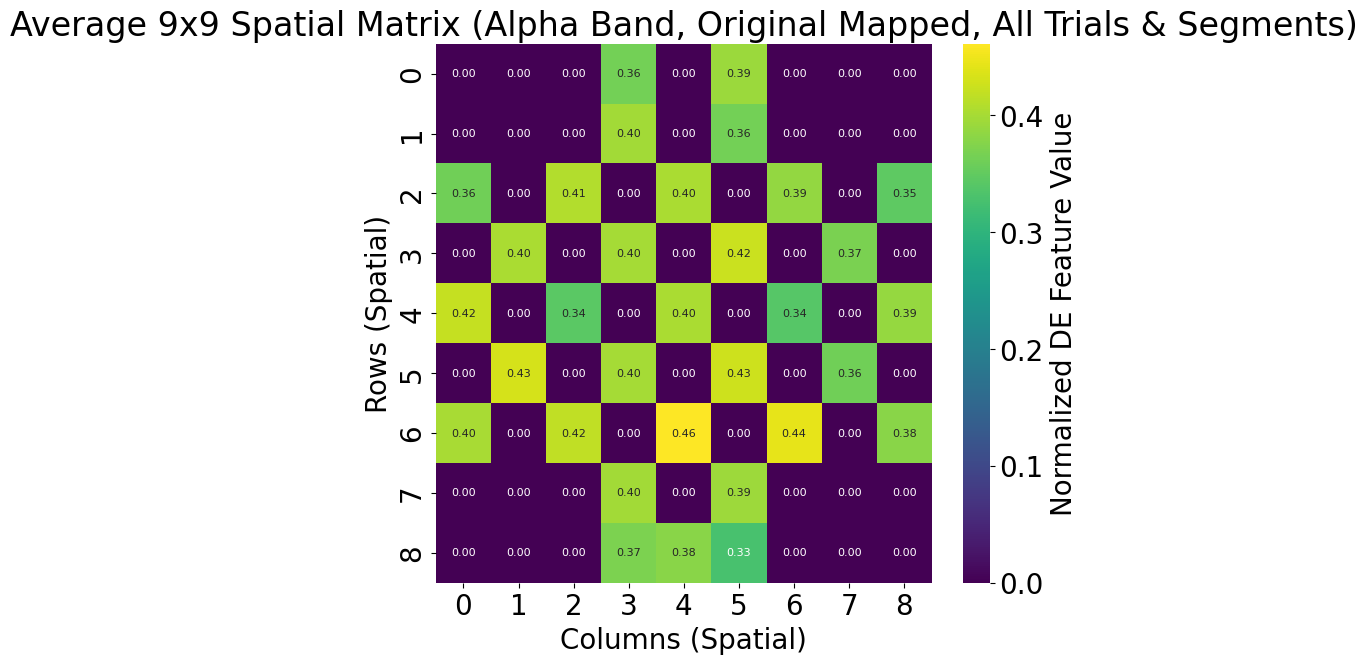

In [ ]:
example_matrix_alpha = final_nn_input_array[:, :, 2, :, :].mean(axis=(0, 1))

plt.figure(figsize=(8, 7))
sns.heatmap(example_matrix_alpha, annot=True, cmap='viridis', fmt=".2f", cbar_kws={'label': 'Normalized DE Feature Value'}, annot_kws={"size": 8})
plt.title('Average 9x9 Spatial Matrix (Alpha Band, Original Mapped, All Trials & Segments)')
plt.xlabel('Columns (Spatial)')
plt.ylabel('Rows (Spatial)')
plt.show()

### Average 9x9 Spatial Matrix for Beta Band

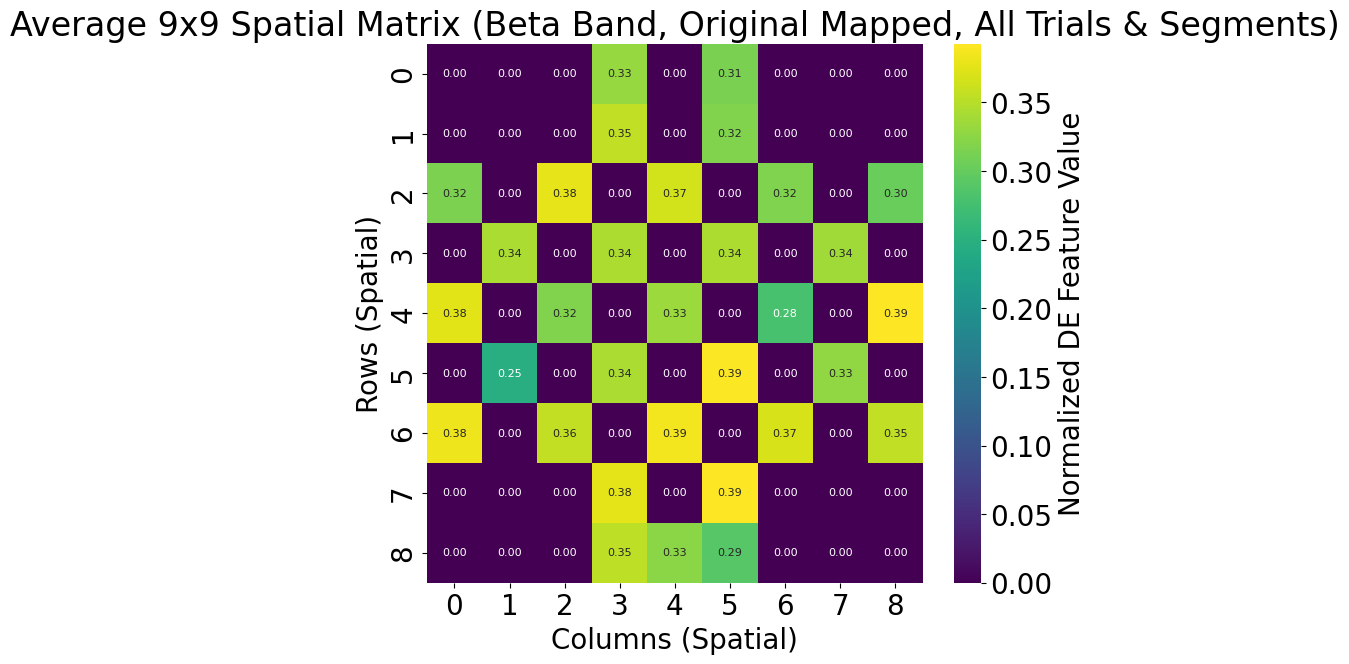

In [ ]:
example_matrix_beta = final_nn_input_array[:, :, 4, :, :].mean(axis=(0, 1))

plt.figure(figsize=(8, 7))
sns.heatmap(example_matrix_beta, annot=True, cmap='viridis', fmt=".2f", cbar_kws={'label': 'Normalized DE Feature Value'}, annot_kws={"size": 8})
plt.title('Average 9x9 Spatial Matrix (Beta Band, Original Mapped, All Trials & Segments)')
plt.xlabel('Columns (Spatial)')
plt.ylabel('Rows (Spatial)')
plt.show()

### Average 9x9 Spatial Matrix for Gamma Band

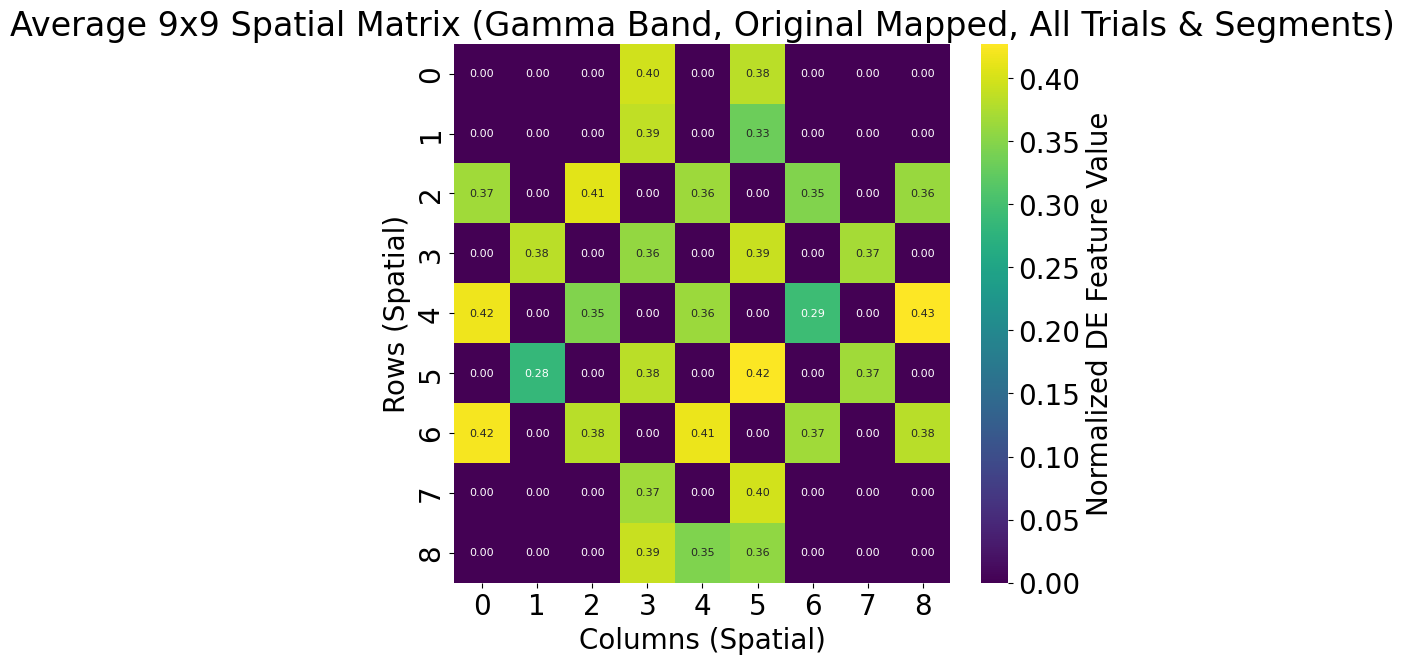

In [ ]:
example_matrix_gamma = final_nn_input_array[:, :, 6, :, :].mean(axis=(0, 1))

plt.figure(figsize=(8, 7))
sns.heatmap(example_matrix_gamma, annot=True, cmap='viridis', fmt=".2f", cbar_kws={'label': 'Normalized DE Feature Value'}, annot_kws={"size": 8})
plt.title('Average 9x9 Spatial Matrix (Gamma Band, Original Mapped, All Trials & Segments)')
plt.xlabel('Columns (Spatial)')
plt.ylabel('Rows (Spatial)')
plt.show()

## Define Model

## Regression model: RNN Model for Emotion Prediction

This section describes a RNN model to predict the four emotion labels (valence, arousal, dominance, liking) using input of **10** subjects of 600 trials. This involves:
1.  **Data Preparation**: Using the DE features as input and the original labels as targets.
2.  **Data Splitting**: Dividing the data into training and testing sets.
3.  **Model Architecture**: Defining a sequential RNN model.
4.  **Model Training**: Training the model on the prepared data.
5.  **Model Evaluation**: Assessing the model's performance.

### Select 10 subjects to improve computing efficiency

In [ ]:
rnn_input_array = final_nn_input_array[:600, :, :, :]
rnn_input_labels = labels[:600, :]
print(f"RNN input array shape: {rnn_input_array.shape}")
print(f"RNN labels shape: {rnn_input_labels.shape}")

RNN input array shape: (600, 60, 8, 9, 9)
RNN labels shape: (600, 4)


### Define and Compile the RNN Model

In [ ]:
# Define the PyTorch RNN model on
class EEG_RNN(torch.nn.Module):
    def __init__(self, input_size, hidden_dim1, hidden_dim2, output_dim, dropout_rate=0.6):
        super(EEG_RNN, self).__init__()

        # First LSTM layer
        self.lstm1 = torch.nn.LSTM(input_size, hidden_dim1, batch_first=True)
        self.dropout1 = torch.nn.Dropout(dropout_rate)

        # Second LSTM layer
        self.lstm2 = torch.nn.LSTM(hidden_dim1, hidden_dim2, batch_first=True)
        self.dropout2 = torch.nn.Dropout(dropout_rate)

        # Output layer
        self.fc = torch.nn.Linear(hidden_dim2, output_dim)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)

        # LSTM 1
        lstm_out1, _ = self.lstm1(x)
        lstm_out1 = self.dropout1(lstm_out1)

        # LSTM 2
        lstm_out2, _ = self.lstm2(lstm_out1)
        lstm_out2 = self.dropout2(lstm_out2)

        # We take the output from the last time step for the final dense layer
        # lstm_out2[:, -1, :] has shape (batch_size, hidden_dim2)
        output = self.fc(lstm_out2[:, -1, :])
        return torch.nn.functional.relu(output) # Added ReLU activation

## Define Hyperparameters

In [ ]:
# Assuming final_nn_input_array shape: (num_trials, num_segments, C, H, W)
# We need to flatten C*H*W to get the input_size for LSTM
num_trials, num_segments, C, H, W = rnn_input_array.shape
input_size = C * H * W
# output_dim for regression was labels.shape[1] (4 emotions)
# For classification, we use num_classes (8 classes)
output_dim_rnn_regression = labels.shape[1] # Retain for initial RNN definition if needed elsewhere

# Hyperparameters for the RNN
hidden_dim1 = 128
hidden_dim2 = 64
dropout_rate = 0.6
batch_size = 20


epochs = 200
patience = 10 # Number of epochs to wait for improvement before stopping
min_delta = 0.001 # Minimum change to be considered an improvement

# Define model
rnn_model_regression = EEG_RNN(input_size, hidden_dim1, hidden_dim2, output_dim_rnn_regression, dropout_rate)

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rnn_model_regression.to(device)

print(rnn_model_regression)
print(f"Regression RNN Model moved to device: {device}")

EEG_RNN(
  (lstm1): LSTM(648, 128, batch_first=True)
  (dropout1): Dropout(p=0.6, inplace=False)
  (lstm2): LSTM(128, 64, batch_first=True)
  (dropout2): Dropout(p=0.6, inplace=False)
  (fc): Linear(in_features=64, out_features=4, bias=True)
)
Regression RNN Model moved to device: cuda


### Data Reshaping and Splitting

First, I will reshape the `final_nn_input_array` to flatten the `C, H, W` dimensions into a single `input_size` for each segment. Then, I will split the data into training and testing sets, ensuring that the labels are also aligned correctly for each trial.

In [ ]:
# Reshape final_nn_input_array for RNN input
# Original shape: (num_trials, num_segments, C, H, W)
# Target shape for LSTM: (num_trials, num_segments, C*H*W)

X_reshaped = rnn_input_array.reshape(num_trials, num_segments, input_size)

# Convert labels to float32 for PyTorch
y_targets = rnn_input_labels.astype(np.float32)

print(f"Reshaped X for RNN input: {X_reshaped.shape}")
print(f"Labels for RNN target: {y_targets.shape}")

# Split data into training and testing sets (e.g., 80% train, 20% test)
# We split at the trial level to maintain independence
num_train_trials = int(num_trials * 0.8)

X_train_np = X_reshaped[:num_train_trials]
y_train_np = y_targets[:num_train_trials]

X_test_np = X_reshaped[num_train_trials:]
y_test_np = y_targets[num_train_trials:]

print(f"X_train shape: {X_train_np.shape}")
print(f"y_train shape: {y_train_np.shape}")
print(f"X_test shape: {X_test_np.shape}")
print(f"y_test shape: {y_test_np.shape}")

Reshaped X for RNN input: (600, 60, 648)
Labels for RNN target: (600, 4)
X_train shape: (480, 60, 648)
y_train shape: (480, 4)
X_test shape: (120, 60, 648)
y_test shape: (120, 4)


### Create PyTorch Datasets and DataLoaders

Now, I'll convert the numpy arrays to PyTorch tensors and create `TensorDataset` and `DataLoader` objects. These will help manage the data during training by providing batches to the model.

In [ ]:
# Convert numpy arrays to PyTorch tensors
X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.float32)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of testing batches: {len(test_loader)}")

Number of training batches: 24
Number of testing batches: 6


### Training and Evaluation Functions

I will define helper functions for training and evaluating the model for clarity and reusability.

In [ ]:
# Define loss function and optimizer
criterion = torch.nn.MSELoss() # For regression problem
optimizer = torch.optim.Adam(rnn_model_regression.parameters(), lr=0.0005)

# Training function
def train_model(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    running_mae = 0.0
    num_samples = 0

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        targets = targets.float() # Ensure targets are float

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        # Calculate MAE
        mae = torch.nn.functional.l1_loss(outputs, targets, reduction='sum').item()
        running_mae += mae
        num_samples += inputs.size(0)

    epoch_loss = running_loss / num_samples
    epoch_mae = running_mae / num_samples
    return epoch_loss, epoch_mae

# Evaluation function
def evaluate_model(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_mae = 0.0
    num_samples = 0
    all_predictions = []
    all_actuals = []

    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            targets = targets.float() # Ensure targets are float

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            # Calculate MAE
            mae = torch.nn.functional.l1_loss(outputs, targets, reduction='sum').item()
            running_mae += mae
            num_samples += inputs.size(0)

            all_predictions.append(outputs.cpu().numpy())
            all_actuals.append(targets.cpu().numpy())

    epoch_loss = running_loss / num_samples
    epoch_mae = running_mae / num_samples
    return epoch_loss, epoch_mae, np.concatenate(all_predictions), np.concatenate(all_actuals)

## Identify Tracked Values

In [ ]:
# Here we are tracking the training losses, testing losses
# and the calculated training MAEs and testing MAEs
train_losses = []
test_losses = []
train_maes = []
test_maes = []

# Because we used early stop so we are also tracking the best test loss,
# patience and best model state
best_test_loss = float('inf')
patience_counter = 0
best_model_state = None

## Train Model

### Train the RNN Model

Now, let's train the `EEG_RNN` model using the prepared data and the defined training function.

In [ ]:
print("Starting training...")
for epoch in range(epochs):
    train_loss, train_mae = train_model(rnn_model_regression, train_loader, criterion, optimizer, device)
    test_loss, test_mae, _, _ = evaluate_model(rnn_model_regression, test_loader, criterion, device) # Using test_loader for test set

    train_losses.append(train_loss)
    train_maes.append(train_mae)
    test_losses.append(test_loss)
    test_maes.append(test_mae)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Train MAE: {train_mae:.4f}, Validation Loss: {test_loss:.4f}, Validation MAE: {test_mae:.4f}")

    # Early stopping logic
    if test_loss < best_test_loss - min_delta:
        best_test_loss = test_loss
        patience_counter = 0
        best_model_state = copy.deepcopy(rnn_model_regression.state_dict()) # Save the best model state
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch + 1} epochs due to no improvement in validation loss.")
            break

print("Training complete.")

# Load the best model state after training
if best_model_state:
    rnn_model_regression.load_state_dict(best_model_state)
    print("Loaded best model state based on validation loss.")

Starting training...
Epoch 1/200, Train Loss: 21.7893, Train MAE: 16.4275, Validation Loss: 17.6755, Validation MAE: 14.3159
Epoch 5/200, Train Loss: 5.3076, Train MAE: 7.5100, Validation Loss: 5.2004, Validation MAE: 7.5972
Epoch 10/200, Train Loss: 4.7525, Train MAE: 7.0252, Validation Loss: 5.1462, Validation MAE: 7.4925
Epoch 15/200, Train Loss: 4.9895, Train MAE: 7.2829, Validation Loss: 5.1734, Validation MAE: 7.5064
Epoch 20/200, Train Loss: 5.0153, Train MAE: 7.2575, Validation Loss: 5.1861, Validation MAE: 7.5218
Early stopping triggered after 22 epochs due to no improvement in validation loss.
Training complete.
Loaded best model state based on validation loss.


## Visualize & Evaluate Model

In [ ]:
# Get predictions and actuals from the last evaluation run
# We need to re-run evaluation to get the predictions and actuals
_, _, predictions, actuals = evaluate_model(rnn_model_regression, test_loader, criterion, device)

# The final test loss (overall MSE) is the last element in the test_losses list
final_test_mse_overall = test_losses[-1]
final_test_rmse_overall = np.sqrt(final_test_mse_overall)

print(f"Overall Final Test MSE: {final_test_mse_overall:.4f}")
print(f"Overall Final Test RMSE: {final_test_rmse_overall:.4f}")

print("\n--- Metrics for Each Emotion ---")

# Assuming there are 4 emotion labels
num_emotions = actuals.shape[1]
emotion_names = ['Valence', 'Arousal', 'Dominance', 'Liking'] # Standard DEAP labels

# Define a threshold for 'accuracy' in regression (e.g., within 1 unit of the actual value)
accuracy_threshold = 1.0 # This can be adjusted based on the scale of your labels

for i in range(num_emotions):
    emotion_actuals = actuals[:, i]
    emotion_predictions = predictions[:, i]

    # Calculate MSE for the current emotion
    emotion_mse = np.mean((emotion_actuals - emotion_predictions)**2)
    emotion_rmse = np.sqrt(emotion_mse)

    # Calculate MAE for the current emotion
    emotion_mae = np.mean(np.abs(emotion_actuals - emotion_predictions))

    # Calculate percentage accuracy based on a threshold
    correct_predictions = np.sum(np.abs(emotion_actuals - emotion_predictions) <= accuracy_threshold)
    total_predictions = len(emotion_actuals)
    percentage_accuracy = (correct_predictions / total_predictions) * 100

    print(f"{emotion_names[i]} RMSE: {emotion_rmse:.4f}, MAE: {emotion_mae:.4f}, Accuracy (within {accuracy_threshold} unit): {percentage_accuracy:.2f}%")

Overall Final Test MSE: 5.1667
Overall Final Test RMSE: 2.2730

--- Metrics for Each Emotion ---
Valence RMSE: 2.1585, MAE: 1.7448, Accuracy (within 1.0 unit): 36.67%
Arousal RMSE: 2.3502, MAE: 1.8401, Accuracy (within 1.0 unit): 38.33%
Dominance RMSE: 2.2146, MAE: 1.9212, Accuracy (within 1.0 unit): 22.50%
Liking RMSE: 2.3338, MAE: 1.9757, Accuracy (within 1.0 unit): 20.83%


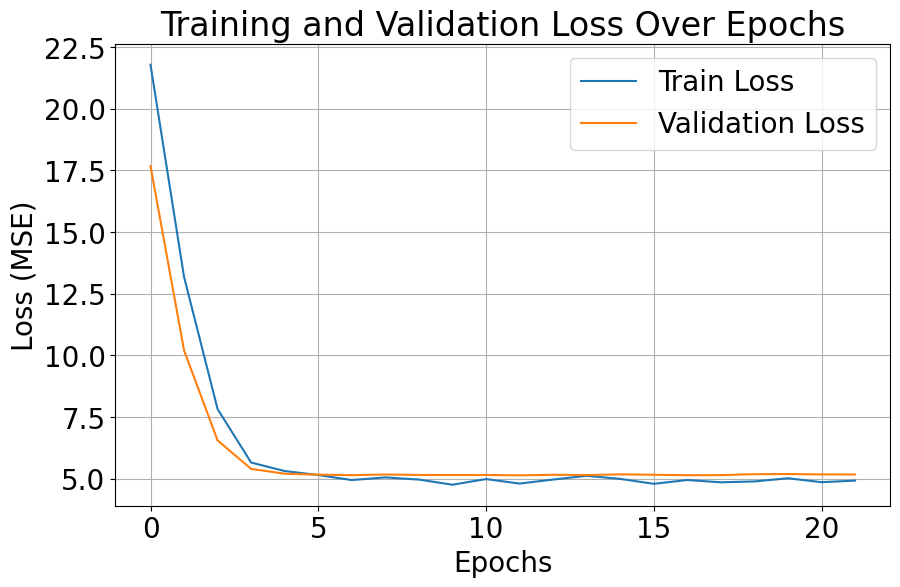

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.savefig('Training and Validation Loss Over Epochs.svg')
plt.show()

------------------------------------------------------------------------------------------------
------------------------------------------------------------------

# Classification model: ACRNN model
Now for a more detailed investigation, we are gonna try to use the ACRNN architecture proposed by the paper

## Prepare Data
Firstly, We will repare the final_nn_input_array and labels for use with the final classifier. This involves reshaping the input data to match the model's expectations and converting the continuous labels into binary classification targets, as well as defining subject ids to track training progress

In [ ]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

num_trials, num_segments, C_bands, H_spatial, W_spatial = final_nn_input_array.shape

# Use all 18 subjects and reshape them
X_de_all = final_nn_input_array.transpose(0, 2, 1, 3, 4).reshape(
    num_trials, C_bands, num_segments, H_spatial * W_spatial
)

y_all = torch.tensor((labels[:, :4] > 5).astype(int), dtype=torch.long)

NUM_CHANNELS_CNN_INPUT = C_bands
NUM_WINDOWS_PER_TRIAL_LSTM_SEQ = num_segments
SAMPLES_PER_WINDOW_CNN_INPUT = H_spatial * W_spatial

print(f"X_de_all shape: {X_de_all.shape}")
print(f"y_all shape: {y_all.shape}")

NUM_SUBJECTS = num_trials // 40
TRIALS_PER_SUBJECT = 40
print(f"Subjects detected: {NUM_SUBJECTS} (× {TRIALS_PER_SUBJECT} trials = {num_trials} total)")

# Create a subject_ids_per_trial array
# This maps each of the 720 trials back to its original subject (0-17)
subject_ids_per_trial = np.repeat(np.arange(NUM_SUBJECTS), TRIALS_PER_SUBJECT)

print(f"Subject IDs per trial shape: {subject_ids_per_trial.shape}")
print(f"Example subject IDs for first 50 trials: {subject_ids_per_trial[:50]}")

Device: cuda
X_de_all shape: (720, 8, 60, 81)
y_all shape: torch.Size([720, 4])
Subjects detected: 18 (× 40 trials = 720 total)
Subject IDs per trial shape: (720,)
Example subject IDs for first 50 trials: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 1 1 1 1 1 1 1 1 1]


## Define Model

### ARCNN sturcture:
According to the paper from Tao et.al, the structurecomposed of

### Summary of Core Model Components

* `ChannelWiseAttention`
    *   **Purpose**: Dynamically recalibrates channel-wise feature responses by learning attention weights for each channel.
    *   **Mechanism**: Uses `AdaptiveMaxPool2d` to condense spatial information, followed by two fully connected layers and an `ELU` activation, culminating in a `sigmoid` activation to produce attention scores (0-1). These scores are then multiplied with the input features, effectively weighting each channel's contribution.

*   `CNN`
    *   **Purpose**: Extracts discriminative features from input data (e.g., EEG segments) by applying convolutional operations.
    *   **Mechanism**: Incorporates `ChannelWiseAttention` first. It then uses two 2D convolutional layers (`conv1` for spatial, `conv2` for temporal patterns), each followed by `BatchNorm2d` and `ELU` activation. `AdaptiveMaxPool2d` is used for global pooling to obtain a fixed-size feature vector per segment. Dropout is applied for regularization.

*  `LSTM`
    *   **Purpose**: Captures long-range temporal dependencies within a sequence of features extracted by the `CNN`.
    *   **Mechanism**: Encapsulates the `CNN` module to first extract features. The resulting sequence of features is then fed into a standard `torch.nn.LSTM` layer(s). Dropout is applied to the LSTM output.

* `SelfAttention`
    *   **Purpose**: Allows the model to weigh the importance of different time steps (segments) in the input sequence, capturing global context.
    *   **Mechanism**: Implements scaled dot-product attention using linear projections for Query (Q), Key (K), and Value (V). It calculates attention scores, applies `softmax` for weighting, and computes a context vector. Dropout is applied to attention weights.

*  `TransformerClassifier`
    *   **Purpose**: The main classification model that integrates the `LSTM` (which includes `ChannelWiseAttention` and `CNN`) and `SelfAttention` for multi-label classification.
    *   **Mechanism**: Processes input data through the `LSTM` backbone to get a sequence of hidden states. These states are then fed into the `SelfAttention` module. The resulting context vector is pooled (mean over time) and passed through a dropout layer. Finally, it uses a `ModuleList` of linear layers (`heads`), one for each emotion dimension, to output binary classification logits.

In [ ]:
# ChannelWise Attention module to extract spatial features

class ChannelWiseAttention(torch.nn.Module):
    def __init__(self, num_channels, reduction_ratio=4):
        super(ChannelWiseAttention, self).__init__()
        self.max_pool = torch.nn.AdaptiveMaxPool2d(1)
        self.fc1 = torch.nn.Linear(num_channels, num_channels // reduction_ratio, bias=False)
        self.elu = torch.nn.ELU()
        self.fc2 = torch.nn.Linear(num_channels // reduction_ratio, num_channels, bias=False)

    def forward(self, x):
        b, c, w, s = x.size()
        se = self.max_pool(x).reshape(b, c)
        se = self.fc1(se)
        se = self.elu(se)
        se = self.fc2(se)
        # Sigmoid: each channel scales independently 0-1
        se = torch.nn.functional.sigmoid(se)
        se = se.reshape(b, c, 1, 1)
        return x * se

In [ ]:
# CNN to understand spatial features
class CNN(torch.nn.Module):
    def __init__(self, num_channels, num_windows_per_trial, samples_per_window, dropout=0.2):
        super(CNN, self).__init__()
        self.channel_attention = ChannelWiseAttention(num_channels)

        num_kernels = 40
        # Layer 1: Spatial convolution — collapses the 8 frequency-band channels
        self.conv1 = torch.nn.Conv2d(1, num_kernels, kernel_size=(3, 5), padding=(1, 2))
        self.bn1 = torch.nn.BatchNorm2d(num_kernels)
        self.elu1 = torch.nn.ELU()

        # Layer 2: Temporal convolution — learns patterns across the 81 spatial features
        self.conv2 = torch.nn.Conv2d(num_kernels, num_kernels, kernel_size=(1, 7), padding=(0,3))
        self.bn2 = torch.nn.BatchNorm2d(num_kernels)
        self.elu2 = torch.nn.ELU()

        self.global_pool = torch.nn.AdaptiveMaxPool2d((1, 1))
        self.dropout = torch.nn.Dropout(dropout)

        # Calculate output feature dimension
        dummy_input = torch.randn(1, 1, num_channels, samples_per_window)
        with torch.no_grad():
            out = self.conv1(dummy_input)
            out = self.conv2(out)
            out = self.global_pool(out)
        self.output_feature_dim = out.numel() // out.shape[0]

    def forward(self, x):
        # x shape: (B, C, W, S) to (batch, bands=8, windows=60, spatial=81)
        B, C, W, S = x.shape
        x = self.channel_attention(x)

        # (B, W, C, S)  to (B*W, 1, C, S) — each segment is an independent CNN sample
        x = x.permute(0, 2, 1, 3).reshape(B * W, 1, C, S)

        x = self.elu1(self.bn1(self.conv1(x)))  # (B*W, 40, 1, S)
        x = self.elu2(self.bn2(self.conv2(x)))  # (B*W, 40, 1, S-39)
        x = self.global_pool(x)                  # (B*W, 40, 1, 1)
        x = self.dropout(x)

        return x.view(B, W, -1)                  # (B, 60, 40)

In [ ]:
# LSTM takes in features extracted from CNN
class LSTM(torch.nn.Module):
    def __init__(self, hidden_size, num_layers, dropout, num_channels, num_windows_per_trial, samples_per_window):
        super(LSTM, self).__init__()
        self.cnn = CNN(num_channels, num_windows_per_trial, samples_per_window, dropout=dropout)

        lstm_input_size = self.cnn.output_feature_dim
        lstm_dropout = dropout if num_layers > 1 else 0
        self.lstm = torch.nn.LSTM(
            input_size=lstm_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=lstm_dropout)
        self.dropout = torch.nn.Dropout(dropout)

    def forward(self, x):
        cnn_output = self.cnn(x)          # (B, 60, 40)
        out, _ = self.lstm(cnn_output)    # (B, 60, hidden_size)
        out = self.dropout(out)
        return out

In [ ]:
# Self attention model takes in input from LSTM to extract temporal features
class SelfAttention(torch.nn.Module):
    def __init__(self, hidden_size, dropout=0.5):
        super(SelfAttention, self).__init__()
        self.hidden_size = hidden_size
        self.Wq = torch.nn.Linear(hidden_size, hidden_size)
        self.Wk = torch.nn.Linear(hidden_size, hidden_size)
        self.Wv = torch.nn.Linear(hidden_size, hidden_size)
        self.attn_dropout = torch.nn.Dropout(dropout)

    def forward(self, h):
        Q = self.Wq(h)
        K = self.Wk(h)
        V = self.Wv(h)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.hidden_size)
        attn_weights = self.attn_dropout(torch.nn.functional.softmax(scores, dim=-1))
        context = torch.matmul(attn_weights, V)
        return context, attn_weights

### Classifier
To link all these models together, we define a **classifier function** here to do classifications. to four heads:

**valence, arousal, dominant, and liking**

In [ ]:
# Define the four heads
DIM_NAMES = ['valence', 'arousal', 'dominance', 'liking']
NUM_DIMS = len(DIM_NAMES)

# Hybrid classifier
class TransformerClassifier(torch.nn.Module):
    """Build a Hybrid model that links four modules together:
     ChannelAttn → CNN → LSTM → SelfAttn → 4 classification heads (VADL)"""
    def __init__(self, num_channels, num_windows_per_trial, samples_per_window,
                 hidden_size=128, num_layers=2, dropout=0.5, num_classes=None):
        super().__init__()
        self.backbone = LSTM(hidden_size, num_layers, dropout,
                             num_channels, num_windows_per_trial, samples_per_window)
        self.attention = SelfAttention(hidden_size, dropout=dropout)
        self.dropout = torch.nn.Dropout(dropout)
        self.heads = torch.nn.ModuleList([
            torch.nn.Linear(hidden_size, 2) for _ in range(NUM_DIMS)
        ])

    def forward(self, x):
        h = self.backbone(x)                    # (B, 60, 128)
        context, _ = self.attention(h)           # (B, 60, 128)
        context = context.mean(dim=1)            # (B, 128) — pool over time
        context = self.dropout(context)
        return [head(context) for head in self.heads]

## Define Hyperparameters

In [ ]:
# Hyperparameters
BATCH_SIZE = 10 # Fixed batch size
HIDDEN_SIZE = 32         # Restored — original proven size
NUM_LAYERS = 2            # Restored — original proven depth
DROPOUT = 0.4            # Increased to 0.6 for more regularization
LEARNING_RATE = 1e-4    # Lower LR for stable convergence
WEIGHT_DECAY = 1e-4
CLIP_NORM = 1.0
EPOCHS = 150

## Identify Tracked Values

In [ ]:
# Store the losses of the single train/val run
all_train_losses = []
all_val_losses = []

overall_val_predictions = [[] for _ in range(NUM_DIMS)]
overall_val_actuals = [[] for _ in range(NUM_DIMS)]

### Train and Evaluate TransformerClassifier Model

This section implements the training and evaluation pipeline for the `TransformerClassifier`. It includes:


1.  **Weighted Cross-Entropy Loss**: For each emotion dimension, a weighted `CrossEntropyLoss` is used to handle potential class imbalances.
4.  **Model Initialization**: A `TransformerClassifier` instance is created with defined hyperparameters and moved to the appropriate device (CPU/GPU).
5.  **Optimizer and Scheduler**: `AdamW` optimizer and `CosineAnnealingLR` scheduler are used for training.
6.  **Training Loop**: The model is trained for a specified number of epochs, with online augmentation (adding small noise to input) and gradient clipping.
7.  **Early Stopping**: Training is stopped early if there's no improvement in validation loss for a certain number of epochs.
8.  **Evaluation**: The model's performance is evaluated on the validation set, and accuracies for each emotion dimension are calculated.
9.  **Results Aggregation**: Mean accuracies across subjects and per-dimension accuracies are collected and printed.

In [ ]:

print("\n--- Performing Single Subject-wise Train/Validation Split ---")

# Shuffle subject indices and split into train and validation sets
# Using 90% of subjects for training, 10% for validation
num_train_subjects = int(NUM_SUBJECTS * 0.9)
shuffled_subject_indices = np.random.permutation(NUM_SUBJECTS)

train_subject_indices = shuffled_subject_indices[:num_train_subjects]
val_subject_indices = shuffled_subject_indices[num_train_subjects:]

print(f"  Training on {len(train_subject_indices)} subjects, Validating on {len(val_subject_indices)} subjects.")

# Get trial indices for the current split
train_trial_indices = np.where(np.isin(subject_ids_per_trial, train_subject_indices))[0]
val_trial_indices = np.where(np.isin(subject_ids_per_trial, val_subject_indices))[0]

# Prepare training and validation data for the current split
X_train_split = X_de_all[train_trial_indices]
y_train_split = y_all[train_trial_indices]
X_val_split = X_de_all[val_trial_indices]
y_val_split = y_all[val_trial_indices]

# Normalization based on training data
mean = X_train_split.mean(axis=(0,2,3), keepdims=True)
std = X_train_split.std(axis=(0,2,3), keepdims=True) + 1e-8

X_train_split = (X_train_split - mean) / std
X_val_split = (X_val_split - mean) / std

print(f"  Train trials shape: {X_train_split.shape}, Val trials shape: {X_val_split.shape}")

# Create TensorDatasets and DataLoaders
train_dataset = TensorDataset(torch.tensor(X_train_split, dtype=torch.float32), y_train_split)
val_dataset = TensorDataset(torch.tensor(X_val_split, dtype=torch.float32), y_val_split)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Per-dimension balanced weights based on the training set of this split
criteria = []
for d in range(NUM_DIMS):
    n0 = (y_train_split[:, d] == 0).sum().float()
    n1 = (y_train_split[:, d] == 1).sum().float()
    N = n0 + n1
    w = torch.tensor([N / (2 * n0) if n0 > 0 else 0.0,
                      N / (2 * n1) if n1 > 0 else 0.0], dtype=torch.float32).to(device)
    criteria.append(torch.nn.CrossEntropyLoss(weight=w))
#------------------------------------------------------------------------------
# Training sections
#------------------------------------------------------------------------------
# Initialize model, optimizer, and scheduler once
model = TransformerClassifier(
    num_channels=NUM_CHANNELS_CNN_INPUT,
    num_windows_per_trial=NUM_WINDOWS_PER_TRIAL_LSTM_SEQ,
    samples_per_window=SAMPLES_PER_WINDOW_CNN_INPUT,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
).to(device)

# Use AdamW as optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Use auto scheduler to change learning rate accordingly
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=20,
    min_lr=1e-6
)

# Dnitialize loss and accuracies
best_val_loss = float('inf')
best_mean_acc = 0.0
best_dim_accs = [0.0] * NUM_DIMS
patience_counter = 0 # early stoping
best_model_state = None

for epoch in range(EPOCHS):
    # -- Train --
    model.train()
    running_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        B = batch_y.size(0)

        #  -- Mild augmentation --
        aug_X = batch_X + torch.randn_like(batch_X) * 0.03

        optimizer.zero_grad()
        logits_list = model(aug_X)
        loss = torch.stack([
            criteria[d](logits_list[d], batch_y[:, d])
            for d in range(NUM_DIMS)
        ]).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), CLIP_NORM)
        optimizer.step()

        running_loss += loss.item()
        train_total += B * NUM_DIMS
        for d in range(NUM_DIMS):
            train_correct += (logits_list[d].argmax(dim=1) == batch_y[:, d]).sum().item()

    # Calculate training loss and training accuracy
    train_loss = running_loss / len(train_loader)
    train_acc = 100.0 * train_correct / train_total
    all_train_losses.append(train_loss) # Store epoch-wise train loss

    # -- evaluation --
    model.eval()
    correct_dim = [0] * NUM_DIMS
    total = 0
    val_loss_sum = 0.0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            logits_list = model(batch_X)
            val_loss_sum += sum(criteria[d](logits_list[d], batch_y[:, d]) for d in range(NUM_DIMS)).item()
            B = batch_y.size(0)
            total += B
            for d in range(NUM_DIMS):
                corr = (logits_list[d].argmax(dim=1) == batch_y[:, d]).sum().item()
                correct_dim[d] += corr
                # Collect predictions and actuals for overall confusion matrix
                overall_val_predictions[d].extend(logits_list[d].argmax(dim=1).cpu().numpy())
                overall_val_actuals[d].extend(batch_y[:, d].cpu().numpy())

    # Calcualte average validation loss and accuracy per emotion dimensions (VADL)
    avg_val_loss = val_loss_sum / len(val_loader)
    val_acc_per_dim = [100.0 * c / total for c in correct_dim]
    val_acc = np.mean(val_acc_per_dim)
    scheduler.step(avg_val_loss)
    all_val_losses.append(avg_val_loss) # Store epoch-wise validation loss

    if epoch == 0 or (epoch + 1) % 10 == 0 or patience_counter == 0 or patience_counter == 1:
        print(f"    Epoch {epoch+1:3d}/{EPOCHS} | Train Loss: {train_loss:.3f} | Val Loss: {avg_val_loss:.3f} | Mean Val Acc: {val_acc:.1f}%")

    # Early stopping
    if avg_val_loss < best_val_loss - 0.001:
        best_val_loss = avg_val_loss
        best_mean_acc = val_acc
        best_dim_accs = val_acc_per_dim.copy()
        best_model_state = model.state_dict() # Save model state
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= 15:
            print(f"    Early stopping triggered after {epoch + 1} epochs due to no improvement in validation loss.")
            break

# Load the best model state if it was saved
if best_model_state:
    model.load_state_dict(best_model_state)
    print("    Loaded best model state for final evaluation.")

#-------------------------------------------------------------------------------
# Summarize final results
#-------------------------------------------------------------------------------
print(f"\n{'='*60}")
print(f"Overall Mean Acc (Single Subject-wise Split): {best_mean_acc:.1f}%")
for d in range(NUM_DIMS):
    print(f"  {DIM_NAMES[d]:>10}: {best_dim_accs[d]:.1f}%")
print(f"{'='*60}")


--- Performing Single Subject-wise Train/Validation Split ---
  Training on 16 subjects, Validating on 2 subjects.
  Train trials shape: (640, 8, 60, 81), Val trials shape: (80, 8, 60, 81)
    Epoch   1/150 | Train Loss: 0.700 | Val Loss: 2.798 | Mean Val Acc: 48.4%
    Epoch   2/150 | Train Loss: 0.695 | Val Loss: 2.757 | Mean Val Acc: 71.2%
    Epoch   3/150 | Train Loss: 0.692 | Val Loss: 2.741 | Mean Val Acc: 77.2%
    Epoch   4/150 | Train Loss: 0.692 | Val Loss: 2.726 | Mean Val Acc: 77.2%
    Epoch   5/150 | Train Loss: 0.691 | Val Loss: 2.731 | Mean Val Acc: 77.2%
    Epoch   6/150 | Train Loss: 0.692 | Val Loss: 2.727 | Mean Val Acc: 77.2%
    Epoch   8/150 | Train Loss: 0.691 | Val Loss: 2.724 | Mean Val Acc: 70.0%
    Epoch   9/150 | Train Loss: 0.691 | Val Loss: 2.737 | Mean Val Acc: 67.2%
    Epoch  10/150 | Train Loss: 0.689 | Val Loss: 2.731 | Mean Val Acc: 68.8%
    Epoch  20/150 | Train Loss: 0.673 | Val Loss: 2.833 | Mean Val Acc: 57.5%
    Early stopping triggered a

## Visualize & Evaluate Model

### Summary of ACRNN Results

Below is a summary of the training and evaluation results for the `ACRNN` model, including:
1. Confusion matrices for four emotion dimensions
2. predicted values compare to the actual values for each emotion dimension across all test trials.
3. MSE for each emotion dimension
4. MAE and RMSE for each emotion dimension

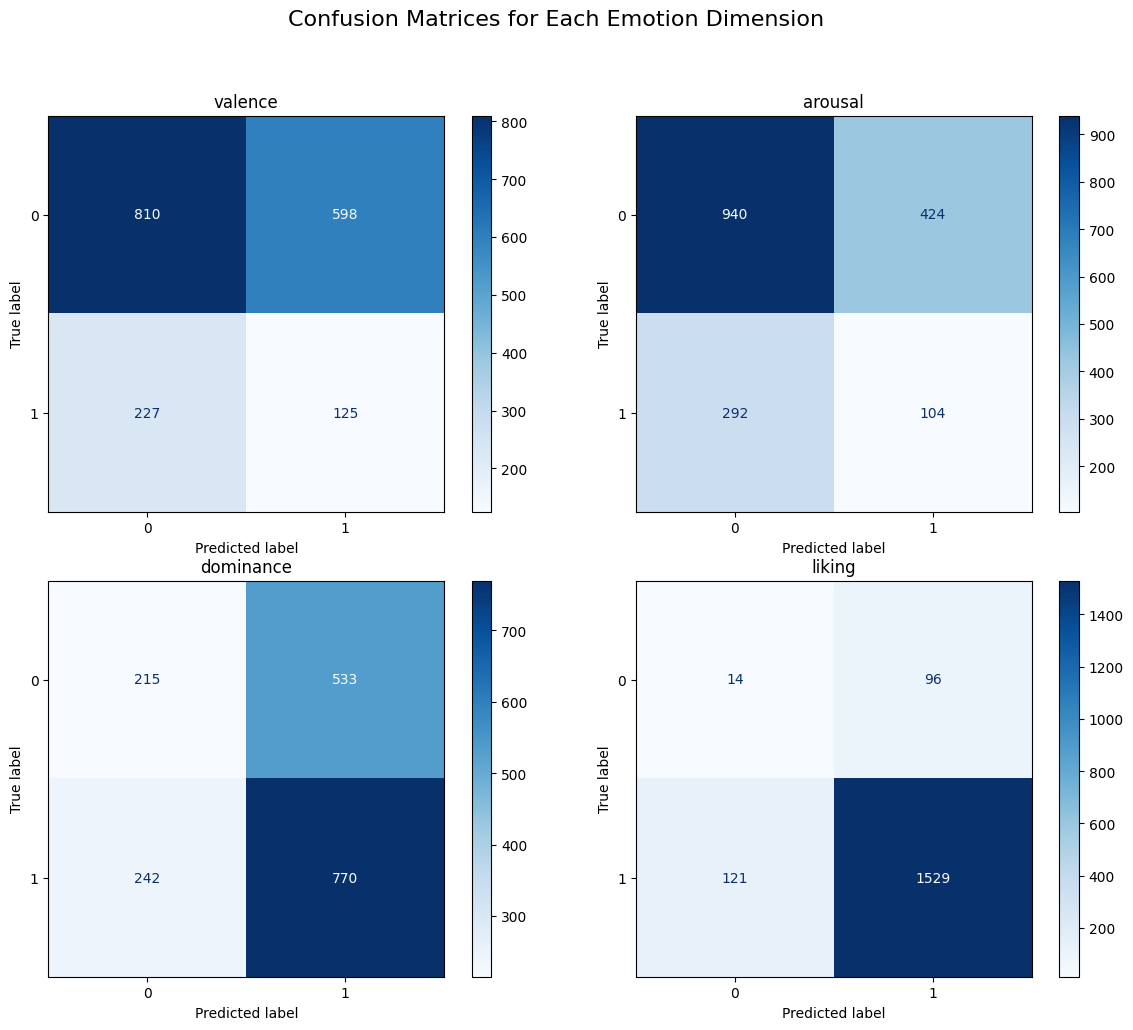

In [ ]:
# Plot the confusion matrices
# Create a single figure with 2x2 subplots for the four emotion dimensions
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten() # Flatten the 2x2 array of axes for easier iteration

fig.suptitle('Confusion Matrices for Each Emotion Dimension', fontsize=16, y=1.02) # Add a main title for the figure

for d in range(NUM_DIMS):
    all_actuals_dim = np.array(overall_val_actuals[d])
    all_predictions_dim = np.array(overall_val_predictions[d])

    if len(all_actuals_dim) == 0:
        print(f"No data for {DIM_NAMES[d]} — skip")
        axes[d].set_visible(False) # Hide subplot if no data
        continue

    cm = confusion_matrix(all_actuals_dim, all_predictions_dim)
    ax = axes[d]
    ConfusionMatrixDisplay(cm, display_labels=[0, 1]).plot(cmap=plt.cm.Blues, ax=ax)
    ax.set_title(f'{DIM_NAMES[d]}')

plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent overlap and make space for suptitle
plt.savefig('all_confusion_matrices.svg') # Save the combined figure
plt.show()

### True vs. Predicted Values Over Trials

Let's visualize how the predicted values compare to the actual values for each emotion dimension across all test trials.

In [ ]:
from sklearn.metrics import classification_report

print("Classification Report for Each Emotion Dimension:")
for d in range(NUM_DIMS):
    actuals_dim = np.array(overall_val_actuals[d])
    predictions_dim = np.array(overall_val_predictions[d])

    if len(actuals_dim) == 0:
        print(f"\nNo data for {DIM_NAMES[d]} to generate classification report.")
        continue

    print(f"\n--- {DIM_NAMES[d]} ---")
    print(classification_report(actuals_dim, predictions_dim, target_names=['0', '1']))

Classification Report for Each Emotion Dimension:

--- valence ---
              precision    recall  f1-score   support

           0       0.78      0.58      0.66      1408
           1       0.17      0.36      0.23       352

    accuracy                           0.53      1760
   macro avg       0.48      0.47      0.45      1760
weighted avg       0.66      0.53      0.58      1760


--- arousal ---
              precision    recall  f1-score   support

           0       0.76      0.69      0.72      1364
           1       0.20      0.26      0.23       396

    accuracy                           0.59      1760
   macro avg       0.48      0.48      0.47      1760
weighted avg       0.64      0.59      0.61      1760


--- dominance ---
              precision    recall  f1-score   support

           0       0.47      0.29      0.36       748
           1       0.59      0.76      0.67      1012

    accuracy                           0.56      1760
   macro avg       0.53  

### Training and Validation Loss Curves

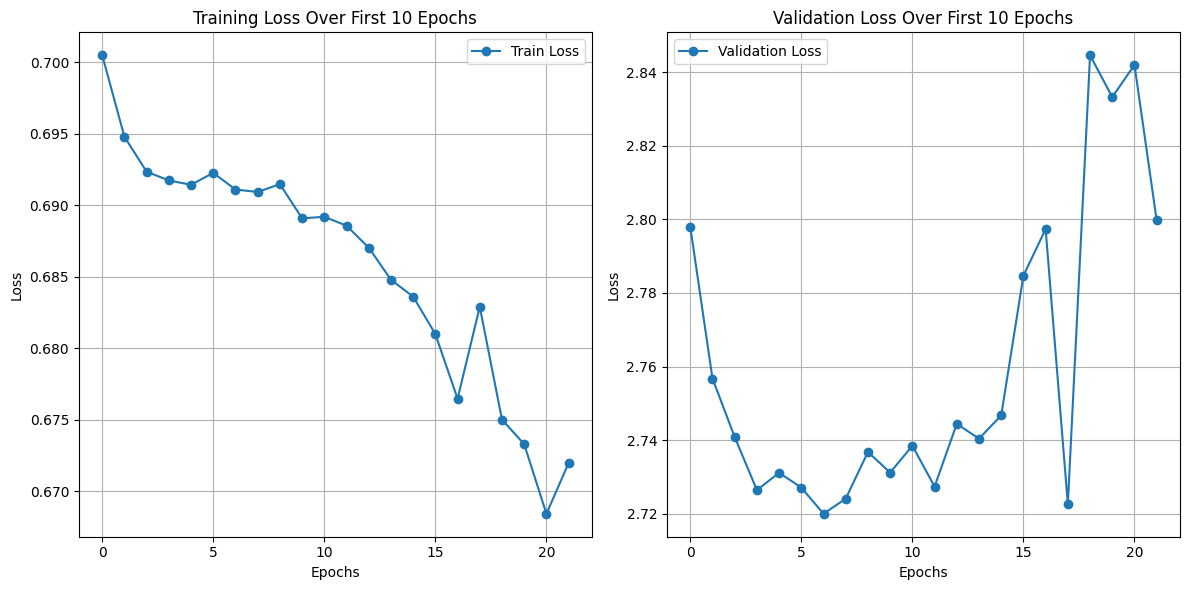

In [ ]:
# Plot the training and validation loss curves across all 22 epochs
num_epochs_to_plot = len(all_train_losses)
plt.figure(figsize=(12, 6))

# Subplot 1: Training Loss
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.plot(all_train_losses[:num_epochs_to_plot], label='Train Loss', marker='o', linestyle='-')
plt.title('Training Loss Over First 10 Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Subplot 2: Validation Loss
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.plot(all_val_losses[:num_epochs_to_plot], label='Validation Loss', marker='o', linestyle='-')
plt.title('Validation Loss Over First 10 Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_validation_loss_curves.svg')
plt.show()

In [ ]:
# Calculate MSE for each emotion dimension
print("Mean Squared Error (MSE) for Each Emotion Dimension:")
for i in range(NUM_DIMS):
    mse = mean_squared_error(actuals[:, i], predictions[:, i])
    print(f"  {emotion_names[i]}: {mse:.4f}")

Mean Squared Error (MSE) for Each Emotion Dimension:
  Valence: 0.4688
  Arousal: 0.4068
  Dominance: 0.4403
  Liking: 0.1233


In [ ]:
# Calculate MAE and RMSE for each emotion dimension

print("\nMean Absolute Error (MAE) and Root Mean Squared Error (RMSE) for Each Emotion Dimension:")
for i in range(NUM_DIMS):
    mae = mean_absolute_error(actuals[:, i], predictions[:, i])
    rmse = np.sqrt(mean_squared_error(actuals[:, i], predictions[:, i]))
    print(f"  {emotion_names[i]}: MAE={mae:.4f}, RMSE={rmse:.4f}")


Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) for Each Emotion Dimension:
  Valence: MAE=0.4688, RMSE=0.6847
  Arousal: MAE=0.4068, RMSE=0.6378
  Dominance: MAE=0.4403, RMSE=0.6636
  Liking: MAE=0.1233, RMSE=0.3511
